# Paper Figures

This notebook generates all figures for the PLANET-MD paper.  
Each subfigure is saved as an editable SVG to `reports/paper_figures/`.

## Prerequisites

Run the following scripts **before** executing this notebook to generate the required pre-computed data.  
Slurm submission commands are in `notebooks/run_prerequisites.sh`.

| # | Script | Outputs |
|---|--------|---------|
| 1 | `scripts/03_evaluate/atlas_validation.py` | `data/evaluation/evaluations/large_model_20250427/{EVAL_KEY}_test_metrics.csv` |
| 2 | `scripts/03_evaluate/plot_runtime.py` | `data/evaluation/evaluations/large_model_20250427/precomputed/runtime_times.json` |
| 3 | `scripts/03_evaluate/compare_rshp_bioemu_dyna.py` | `precomputed/{test_rmse_by_size.csv, test_spearman_by_size.csv, test_imsd_by_size.csv}` |
| 4 | `scripts/04_downstream/relaxDB/rshp_relaxdb_infer.py` | `<relaxdb_root>/rxdb_rocketshp_npz/*.npz` |
| 5 | `scripts/03_evaluate/mdcath_temperature.py` | `data/evaluation/evaluations/mdcath_large_ep10/precomputed/{temperature_joint_results.csv, temperature_case_study.npz}` |
| 6 | `scripts/04_downstream/weng_KRAS/03_eval_and_plot.py` | `reports/large_model_20250427/precomputed/{kras_res_df.csv, kras_folding_ddg.csv, kras_wild_type_centrality.json}` |
| 7 | `scripts/04_downstream/weng_KRAS/04_visualize_kras_networks.py` | `reports/large_model_20250427/precomputed/{kras_wt_masked_network.npz, kras_gcc_lmi_clusters.json}` |
| 8 | `scripts/04_downstream/proteome_scale/human_proteome_analyze.py` | `data/processed/rocketshp_afdb_human/precomputed/{disordered_rmsf.csv, subcellular_location_counts.csv, subcellular_location_rmsf.csv}` |
| 9 | `scripts/03_evaluate/atlas_validation.py --eval_key struct_encoded ...` | `data/evaluation/evaluations/struct_encoded/struct_encoded_test_metrics.csv` |
| 10 | `scripts/03_evaluate/atlas_validation.py --eval_key seq_only ...` | `data/evaluation/evaluations/seq_only/seq_only_test_metrics.csv` |

> **Fig 7 note:** Steps 9 and 10 run the same `atlas_validation.py` script against the structure-ablation checkpoints (`struct_encoded` and `seq_only`). Pass the appropriate `--eval_key`, `--config_file`, and `--model` arguments for each ablation checkpoint. The script now writes both `.pkl` and `.csv`; the notebook reads the `.csv`.

In [2]:
from itertools import combinations
import json
import pickle as pk
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy.stats import pearsonr
from statannotations.Annotator import Annotator
from torch.nn.functional import relu

from rocketshp import config
from rocketshp.network import display_network, pairwise_correlation_to_network

# ── Color palette ──────────────────────────────────────────────────────────
COLORS = {
    "PLANET-MD": "#247d3d",
    "PLANET-MD mini": "#74c476",
    "Dyna-1": "#2171b5",
    "Dyna-1 (Calibrated)": "#6baed6",
    "BioEmu (10 samples)": "#756bb1",
    "BioEmu (100 samples)": "#3f007d",
    "BioEmu (10)": "#756bb1",
    "BioEmu (100)": "#3f007d",
    "Exponential Thermal Dependence": "#d94801",
    "AF-Cluster": "#d94801",
    "All-Atom Simulation": "#252525",
}

# ── Shared colors ──────────────────────────────────────────────────────────
struct_color = COLORS["PLANET-MD"]
seq_color = "#888888"

# ── Shared figure sizes ────────────────────────────────────────────────────
FIG_WIDE = (12, 8)
FIG_SQUARE = (8, 8)
FIG_SMALL = (5, 5)
FONT_SIZE = 24

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.5,
    "axes.facecolor": "none",
    "axes.grid": False,
    "figure.facecolor": "none",
    "savefig.transparent": True,
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "text.color": "black",
    "font.size": FONT_SIZE,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
    "svg.fonttype": "none",
    "legend.markerscale": 3.0,
    "legend.handlelength": 2.0,
    "legend.frameon": False,
})


def finalize(ax=None):
    """Remove top/right spines and force remaining spines + ticks to black.
    Use this instead of sns.despine() — seaborn's despine resets spine colors."""
    if ax is None:
        ax = plt.gca()
    for a in np.ravel(ax):
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)
        for side in ("left", "bottom"):
            a.spines[side].set_edgecolor("black")
            a.spines[side].set_linewidth(1.5)
        a.tick_params(colors="black", width=1.5)
        a.grid(False)
        a.set_facecolor("none")


SVG_DIR = config.REPORTS_DIR / "paper_figures"
SVG_DIR.mkdir(parents=True, exist_ok=True)
print(f"SVGs will be saved to: {SVG_DIR}")

SVGs will be saved to: /mnt/home/ssledzieski/Projects/rocketshp/reports/paper_figures


In [3]:
EVAL_KEY = "large_model_20250427"
SPLIT = "test"
MDCATH_EVAL_KEY = "mdcath_large_ep10"
TEMP_LIST = ["320", "348", "379", "413", "450"]

ATLAS_PRECOMPUTED = config.EVALUATION_DATA_DIR / "evaluations" / EVAL_KEY / "precomputed"
ATLAS_EVAL_DIR = config.EVALUATION_DATA_DIR / "evaluations" / EVAL_KEY
MDCATH_PRECOMPUTED = config.EVALUATION_DATA_DIR / "evaluations" / MDCATH_EVAL_KEY / "precomputed"
KRAS_PRECOMPUTED = config.REPORTS_DIR / EVAL_KEY / "precomputed"
RELAXDB_ROOT = Path("/mnt/home/ssledzieski/GitHub/Dyna-1/data/RelaxDB_datasets")
PROTEOME_PRECOMPUTED = config.PROCESSED_DATA_DIR / "rocketshp_afdb_human" / "precomputed"

# Dataset sizes for Fig 6a
ATLAS_SIZE = 1_389
PROTEOME_SIZE = 25_000
SWISSPROT_SIZE = 500_000
AFDB_SIZE = 200_000_000
seconds = 1
minutes = 60
hours = 3600
days = 86400

## Fig 2a — ATLAS Runtime Distribution

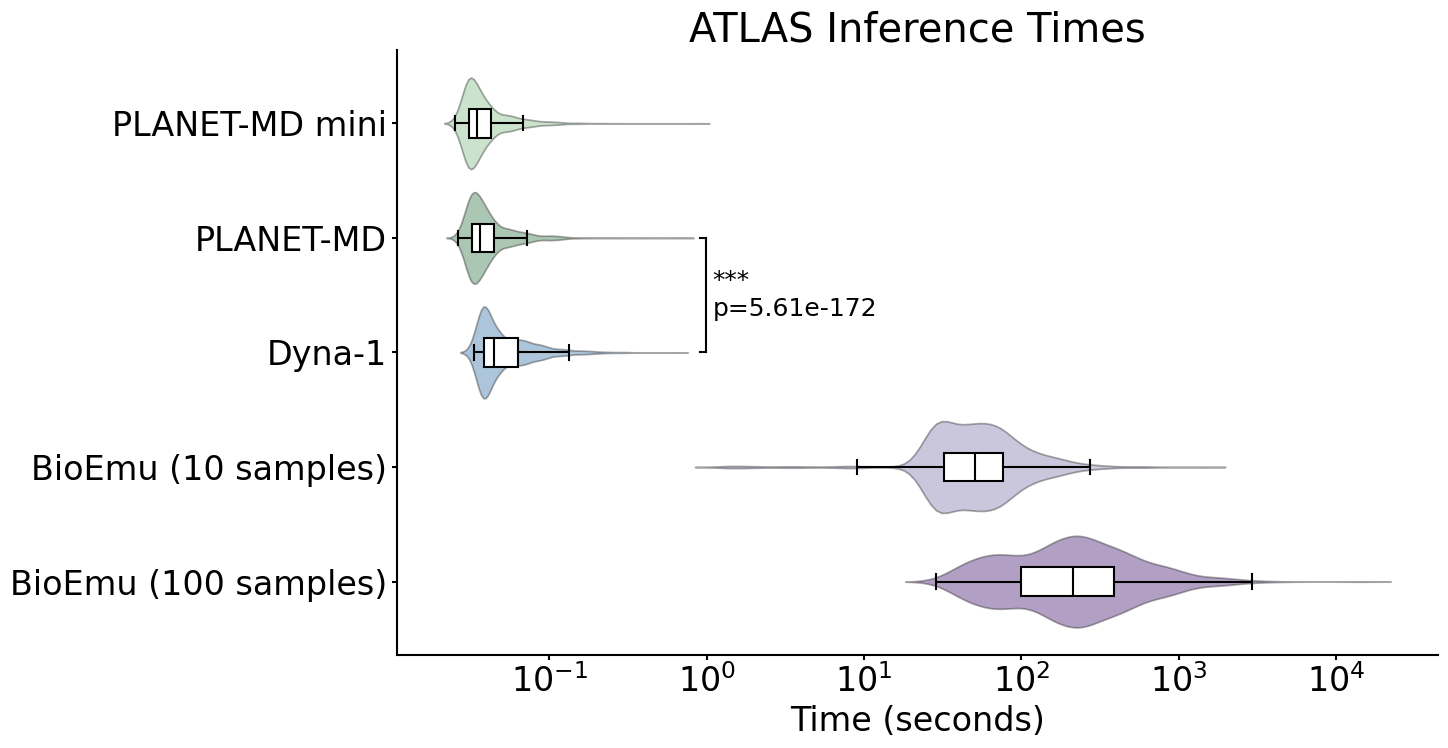

In [86]:
with open(ATLAS_PRECOMPUTED / "runtime_times.json") as f:
    runtime_times = json.load(f)

order = [
    "PLANET-MD mini",
    "PLANET-MD",
    "Dyna-1",
    "BioEmu (10 samples)",
    "BioEmu (100 samples)",
]
palette = [COLORS[n] for n in order]

n_min = min(len(runtime_times[k]) for k in order)
time_df = pd.DataFrame({k: runtime_times[k][:n_min] for k in order})
melted = time_df.melt()
melted["value"] = np.log10(melted["value"])

fig, ax = plt.subplots(figsize=(15,8))
sns.violinplot(
    data=melted, x="value", y="variable",
    hue="variable", order=order, hue_order=order,
    palette=palette, orient="h", inner=None, alpha=0.4, legend=False,
)
sns.boxplot(
    data=melted, x="value", y="variable",
    hue="variable", order=order, hue_order=order,
    palette=palette, orient="h", width=0.25, fliersize=0, linewidth=1.5,
    boxprops=dict(facecolor="white", edgecolor="black"),
    medianprops=dict(color="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    legend=False,
)
tick_vals = [-2, -1, 0, 1, 2, 3, 4]
ax.set_xticks(tick_vals)
ax.set_xticklabels([f"$10^{{{v}}}$" for v in tick_vals])
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("")
ax.set_title("ATLAS Inference Times")
finalize(ax)

# ── Significance test: PLANET-MD vs Dyna-1 (paired Wilcoxon, log-scale) ──
from scipy.stats import wilcoxon
_planet = np.array(runtime_times["PLANET-MD"][:n_min])
_dyna   = np.array(runtime_times["Dyna-1"][:n_min])
_stat, _p = wilcoxon(_planet, _dyna, alternative="less")

def _p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

# y positions in the violin plot correspond to order indices (0-based)
_y_planet = order.index("PLANET-MD")
_y_dyna   = order.index("Dyna-1")
_x_bracket = ax.get_xlim()[1] * 0.97  # near right edge
_bracket_kw = dict(color="black", linewidth=1.5, clip_on=False)
_x_tick = np.log10(max(_planet.max(), _dyna.max())) + 0.15
ax.plot([_x_tick, _x_tick], [_y_planet, _y_dyna], **_bracket_kw)
ax.plot([_x_tick - 0.04, _x_tick], [_y_planet, _y_planet], **_bracket_kw)
ax.plot([_x_tick - 0.04, _x_tick], [_y_dyna,   _y_dyna],   **_bracket_kw)
ax.text(_x_tick + 0.04, (_y_planet + _y_dyna) / 2,
        f"{_p_to_stars(_p)}\np={_p:.2e}",
        va="center", ha="left", fontsize=18, clip_on=False)

plt.tight_layout()
plt.savefig(SVG_DIR / "fig2a_runtime_distribution.svg")
plt.show()

## Fig 2b — Spearman Correlation vs. -log10(p), by sequence length

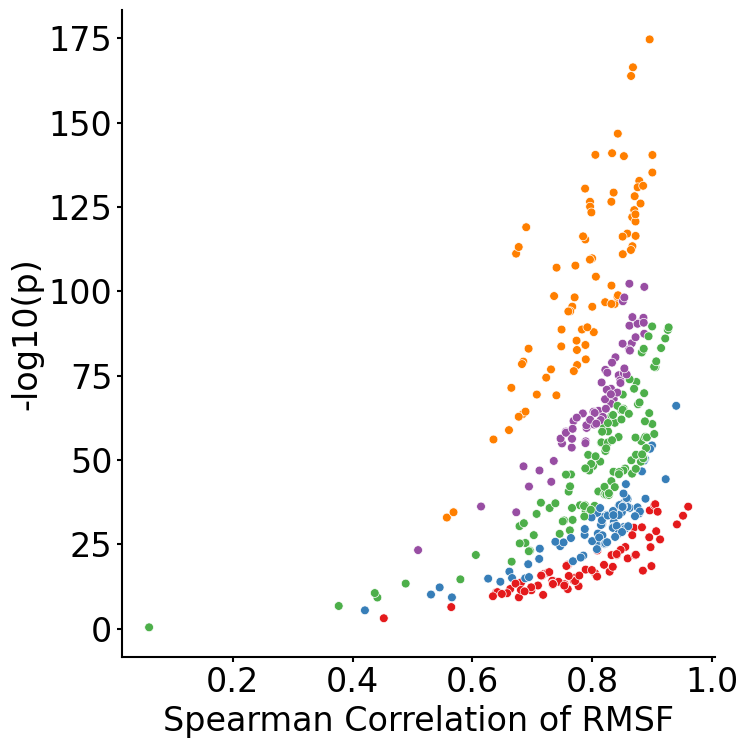

In [95]:
test_metrics = pd.read_csv(ATLAS_EVAL_DIR / f"{EVAL_KEY}_test_metrics.csv")

length_order = [
    "<100 residues", "100-149 residues", "150-249 residues",
    "250-349 residues", ">350 residues",
]
test_metrics["Sequence Length"] = pd.Categorical(
    test_metrics["Sequence Length"], categories=length_order, ordered=True
)

# Distinct categorical colors (ColorBrewer Set1) — shared with 2c/2d
length_palette = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]

fig, ax = plt.subplots(figsize=FIG_SQUARE)
sns.scatterplot(
    data=test_metrics,
    x="rmsf_spearman_r",
    y=-np.log10(test_metrics["rmsf_spearman_p"]),
    hue="Sequence Length",
    hue_order=length_order,
    palette=length_palette,
    s=40,
    legend=False,
    ax=ax,
)
ax.set_xlabel("Spearman Correlation of RMSF")
ax.set_ylabel("-log10(p)")
finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig2b_spearman_scatter.svg")
plt.show()

## Fig 2c — RMSE of RMSF by method and sequence length

/tmp/ipykernel_978849/2551042670.py:10: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.boxplot(
/tmp/ipykernel_978849/2551042670.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")


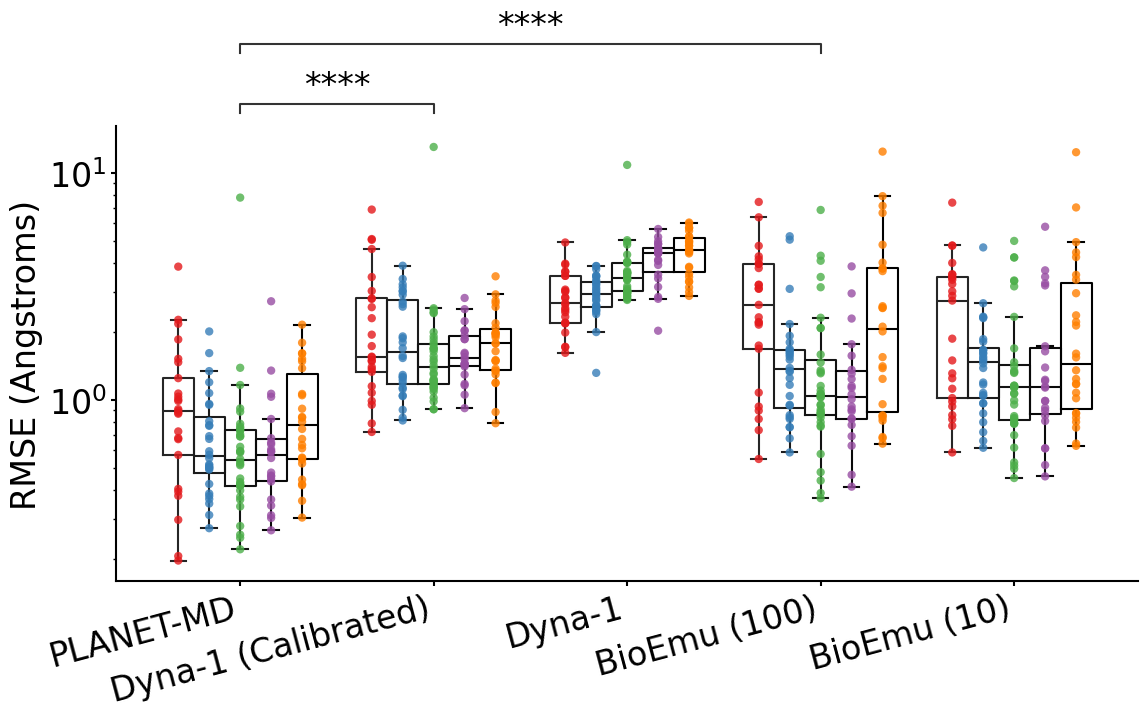

RMSE  PLANET-MD vs Dyna-1 (Calibrated): U=1963, p=1.102e-29, n=137 vs 137
RMSE  PLANET-MD vs BioEmu (100): U=3466, p=1.820e-19, n=137 vs 137


In [96]:
rmse_df = pd.read_csv(ATLAS_PRECOMPUTED / f"{SPLIT}_rmse_by_size.csv")
rmse_df["RMSE"] = rmse_df["RMSE"] * 10  # nm → Å

order = ["PLANET-MD", "Dyna-1 (Calibrated)", "Dyna-1", "BioEmu (100)", "BioEmu (10)"]
size_group_order = ["0 - 99", "100 - 149", "150 - 249", "250 - 349", "350 - 1049"]
size_palette = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]
color_map = dict(zip(size_group_order, size_palette))

fig, ax = plt.subplots(figsize=FIG_WIDE)
sns.boxplot(
    x="Method", y="RMSE", hue="Size Group",
    data=rmse_df, linewidth=1.5, fliersize=0,
    order=order, hue_order=size_group_order,
    fill=False, legend=False, color="black", ax=ax,
)
for sg in size_group_order:
    subset = rmse_df[rmse_df["Size Group"] == sg]
    method_positions = {m: j for j, m in enumerate(order)}
    n_groups = len(size_group_order)
    i = size_group_order.index(sg)
    offset = (i - (n_groups - 1) / 2) * 0.8 / n_groups
    x_pos = [method_positions[m] + offset for m in subset["Method"]]
    ax.scatter(
        x_pos, subset["RMSE"],
        marker="o", s=36, alpha=0.8,
        color=color_map[sg], edgecolor="none",
        zorder=3,
    )
ax.set_yscale("log")
ax.set_ylabel("RMSE (Angstroms)")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")

pairs = [("PLANET-MD", "Dyna-1 (Calibrated)"), ("PLANET-MD", "BioEmu (100)")]
annotator = Annotator(ax, pairs, data=rmse_df, x="Method", y="RMSE", order=order)
annotator.configure(test="Mann-Whitney", text_format="star", loc="outside", verbose=0)
annotator.apply_and_annotate()

finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig2c_rmse_by_size.svg")
plt.show()
# ── Significance stats for caption ──────────────────────────────────────
from scipy.stats import mannwhitneyu as _mwu
for _a, _b in [("PLANET-MD", "Dyna-1 (Calibrated)"), ("PLANET-MD", "BioEmu (100)")]:
    _x = rmse_df.loc[rmse_df["Method"] == _a, "RMSE"].values
    _y = rmse_df.loc[rmse_df["Method"] == _b, "RMSE"].values
    _u, _p = _mwu(_x, _y, alternative="two-sided")
    print(f"RMSE  {_a} vs {_b}: U={_u:.0f}, p={_p:.3e}, n={len(_x)} vs {len(_y)}")


## Fig 2c (violin) — RMSE of RMSF by method and sequence length

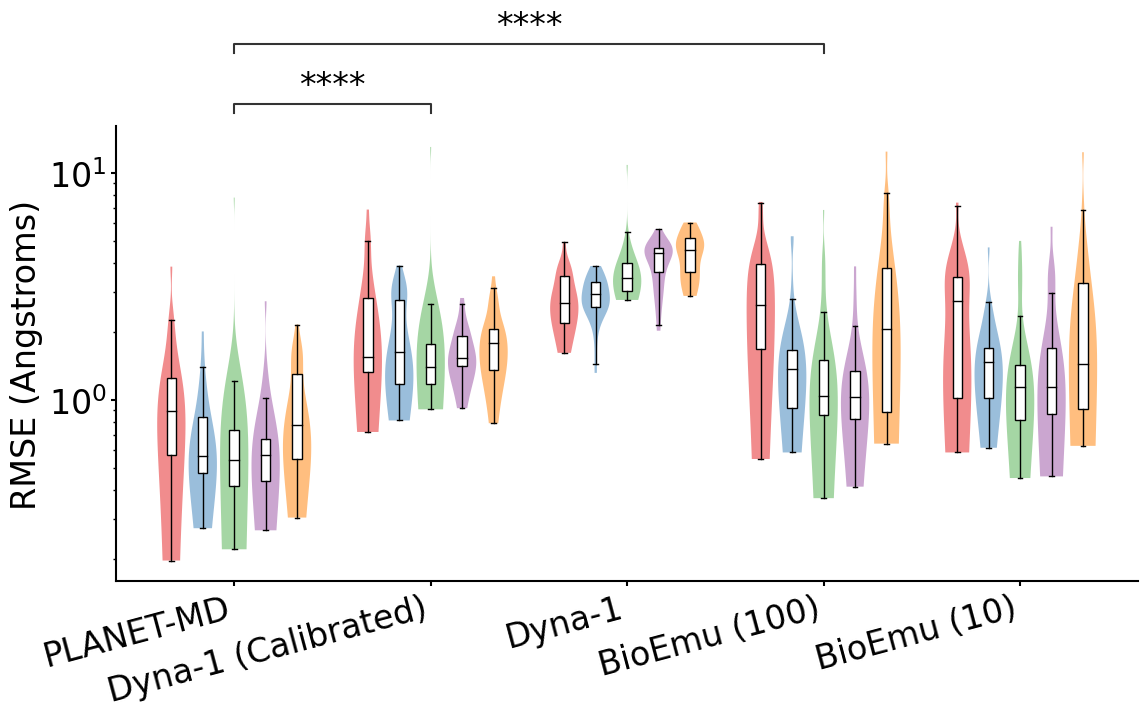

RMSE (violin)  PLANET-MD vs Dyna-1 (Calibrated): U=1963, p=1.102e-29, n=137 vs 137
RMSE (violin)  PLANET-MD vs BioEmu (100): U=3466, p=1.820e-19, n=137 vs 137


In [97]:
order = ["PLANET-MD", "Dyna-1 (Calibrated)", "Dyna-1", "BioEmu (100)", "BioEmu (10)"]

def _violin_box_hue(ax, df, x_col, y_col, hue_col, x_order, hue_order, hue_colors):
    """Violin + box for a categorical x with a hue grouping."""
    n_hue = len(hue_order)
    total_w = 0.8
    slot_w = total_w / n_hue
    box_w = slot_w * 0.3
    offsets = [(i - (n_hue - 1) / 2) * slot_w for i in range(n_hue)]

    for xi, xval in enumerate(x_order):
        for hi, (hval, color) in enumerate(zip(hue_order, hue_colors)):
            vals = df.loc[(df[x_col] == xval) & (df[hue_col] == hval), y_col].dropna().values
            if len(vals) < 2:
                continue
            xc = xi + offsets[hi]
            if vals.std() > 1e-9:
                vp = ax.violinplot(vals, positions=[xc], widths=slot_w * 0.9,
                                   showmeans=False, showmedians=False, showextrema=False)
                for body in vp["bodies"]:
                    body.set_facecolor(color)
                    body.set_alpha(0.5)
                    body.set_edgecolor("none")
            q1, med, q3 = np.percentile(vals, [25, 50, 75])
            iqr = q3 - q1
            lo = max(vals.min(), q1 - 1.5 * iqr)
            hi_w = min(vals.max(), q3 + 1.5 * iqr)
            bw = box_w
            rect = mpatches.FancyBboxPatch(
                (xc - bw / 2, q1), bw, iqr,
                boxstyle="square,pad=0",
                linewidth=1.0, edgecolor="black", facecolor="white", zorder=3,
            )
            ax.add_patch(rect)
            ax.plot([xc - bw / 2, xc + bw / 2], [med, med],
                    color="black", linewidth=1.0, zorder=4)
            ax.plot([xc, xc], [q1, lo], color="black", linewidth=1.0, zorder=3)
            ax.plot([xc, xc], [q3, hi_w], color="black", linewidth=1.0, zorder=3)
            cap_w = bw * 0.5
            for cap_y in [lo, hi_w]:
                ax.plot([xc - cap_w / 2, xc + cap_w / 2], [cap_y, cap_y],
                        color="black", linewidth=1.0, zorder=3)

    ax.set_xticks(range(len(x_order)))
    ax.set_xticklabels(x_order, rotation=15, ha="right")
    ax.set_xlim(-0.6, len(x_order) - 0.4)


fig, ax = plt.subplots(figsize=FIG_WIDE)
_violin_box_hue(ax, rmse_df, "Method", "RMSE", "Size Group",
                order, size_group_order, size_palette)
ax.set_yscale("log")
ax.set_ylabel("RMSE (Angstroms)")
ax.set_xlabel("")

pairs = [("PLANET-MD", "Dyna-1 (Calibrated)"), ("PLANET-MD", "BioEmu (100)")]
annotator = Annotator(ax, pairs, data=rmse_df, x="Method", y="RMSE", order=order)
annotator.configure(test="Mann-Whitney", text_format="star", loc="outside", verbose=0)
annotator.apply_and_annotate()

finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig2c_rmse_by_size_violin.svg")
plt.show()

# ── Significance stats for caption ──────────────────────────────────────
from scipy.stats import mannwhitneyu as _mwu
for _a, _b in [("PLANET-MD", "Dyna-1 (Calibrated)"), ("PLANET-MD", "BioEmu (100)")]:
    _x = rmse_df.loc[rmse_df["Method"] == _a, "RMSE"].values
    _y = rmse_df.loc[rmse_df["Method"] == _b, "RMSE"].values
    _u, _p = _mwu(_x, _y, alternative="two-sided")
    print(f"RMSE (violin)  {_a} vs {_b}: U={_u:.0f}, p={_p:.3e}, n={len(_x)} vs {len(_y)}")


## Fig 2d — IMSD of GCC-LMI by method and sequence length

/tmp/ipykernel_978849/1927868485.py:10: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.boxplot(
/tmp/ipykernel_978849/1927868485.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")


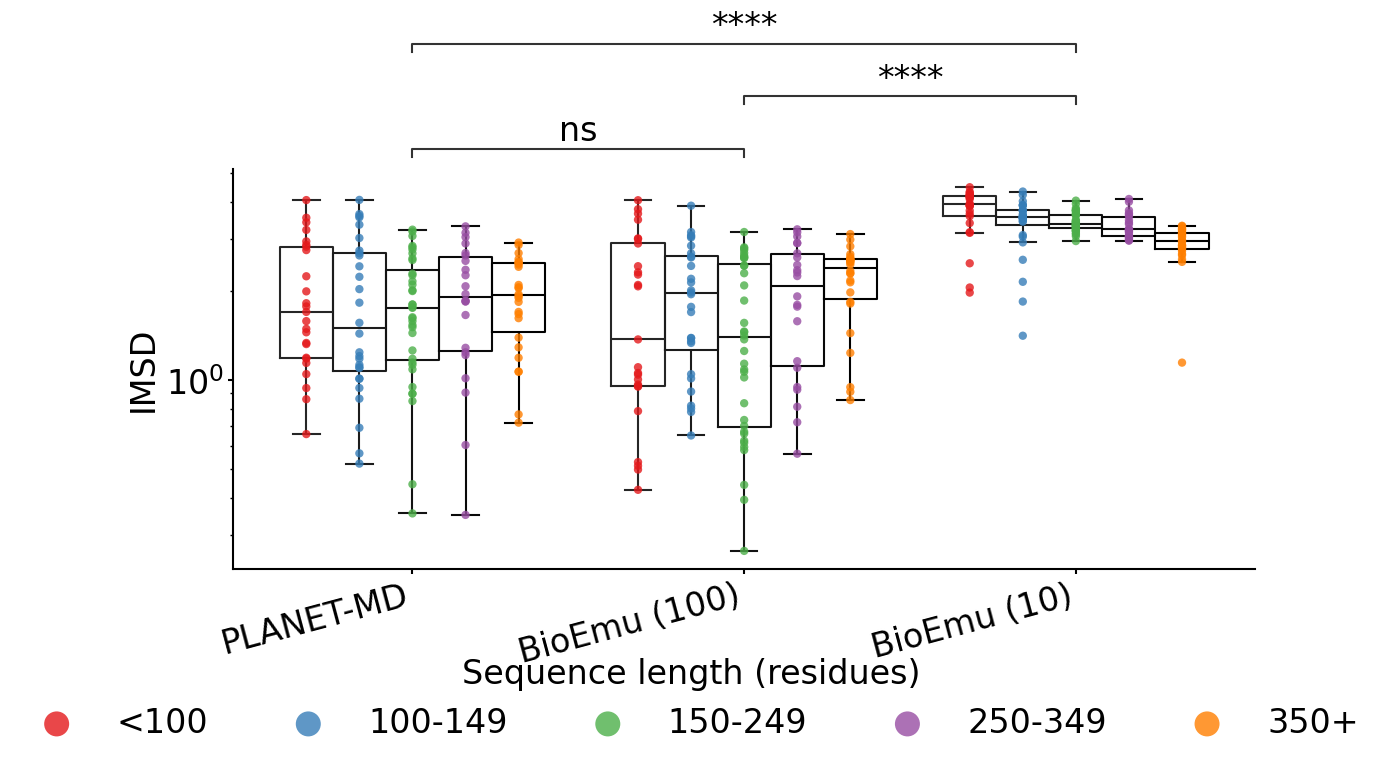

IMSD  PLANET-MD vs BioEmu (100): U=9598, p=7.454e-01, n=137 vs 137
IMSD  PLANET-MD vs BioEmu (10): U=1582, p=1.238e-32, n=137 vs 137
IMSD  BioEmu (100) vs BioEmu (10): U=1452, p=1.130e-33, n=137 vs 137


In [98]:
imsd_df = pd.read_csv(ATLAS_PRECOMPUTED / f"{SPLIT}_imsd_by_size.csv")

order = ["PLANET-MD", "BioEmu (100)", "BioEmu (10)"]
size_group_order = ["0 - 99", "100 - 149", "150 - 249", "250 - 349", "350 - 1049"]
size_group_labels = ["<100", "100-149", "150-249", "250-349", "350+"]
size_palette = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]
color_map = dict(zip(size_group_order, size_palette))

fig, ax = plt.subplots(figsize=FIG_WIDE)
sns.boxplot(
    x="Method", y="IMSD", hue="Size Group",
    data=imsd_df, linewidth=1.5, fliersize=0,
    order=order, hue_order=size_group_order,
    fill=False, legend=False, color="black", ax=ax,
)
for sg in size_group_order:
    subset = imsd_df[imsd_df["Size Group"] == sg]
    method_positions = {m: j for j, m in enumerate(order)}
    n_groups = len(size_group_order)
    i = size_group_order.index(sg)
    offset = (i - (n_groups - 1) / 2) * 0.8 / n_groups
    x_pos = [method_positions[m] + offset for m in subset["Method"]]
    ax.scatter(
        x_pos, subset["IMSD"],
        marker="o", s=36, alpha=0.8,
        color=color_map[sg], edgecolor="none",
        label=size_group_labels[size_group_order.index(sg)],
        zorder=3,
    )
ax.set_yscale("log")
ax.set_ylabel("IMSD")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")

# Legend outside below the axes, can be wider than the plot
handles, labels = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = h
fig.legend(
    seen.values(), seen.keys(),
    title="Sequence length (residues)",
    loc="lower center", bbox_to_anchor=(0.5, -0.08),
    ncol=len(size_group_order), frameon=False,
)

pairs = list(combinations(order, 2))
annotator = Annotator(ax, pairs, data=imsd_df, x="Method", y="IMSD", order=order)
annotator.configure(test="Mann-Whitney", text_format="star", loc="outside", verbose=0)
annotator.apply_and_annotate()

finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig2d_imsd_by_size.svg")
plt.show()

# ── Significance stats for caption ──────────────────────────────────────
from scipy.stats import mannwhitneyu as _mwu
for _a, _b in combinations(["PLANET-MD", "BioEmu (100)", "BioEmu (10)"], 2):
    _x = imsd_df.loc[imsd_df["Method"] == _a, "IMSD"].values
    _y = imsd_df.loc[imsd_df["Method"] == _b, "IMSD"].values
    _u, _p = _mwu(_x, _y, alternative="two-sided")
    print(f"IMSD  {_a} vs {_b}: U={_u:.0f}, p={_p:.3e}, n={len(_x)} vs {len(_y)}")


## Fig 2d (violin) — IMSD of GCC-LMI by method and sequence length

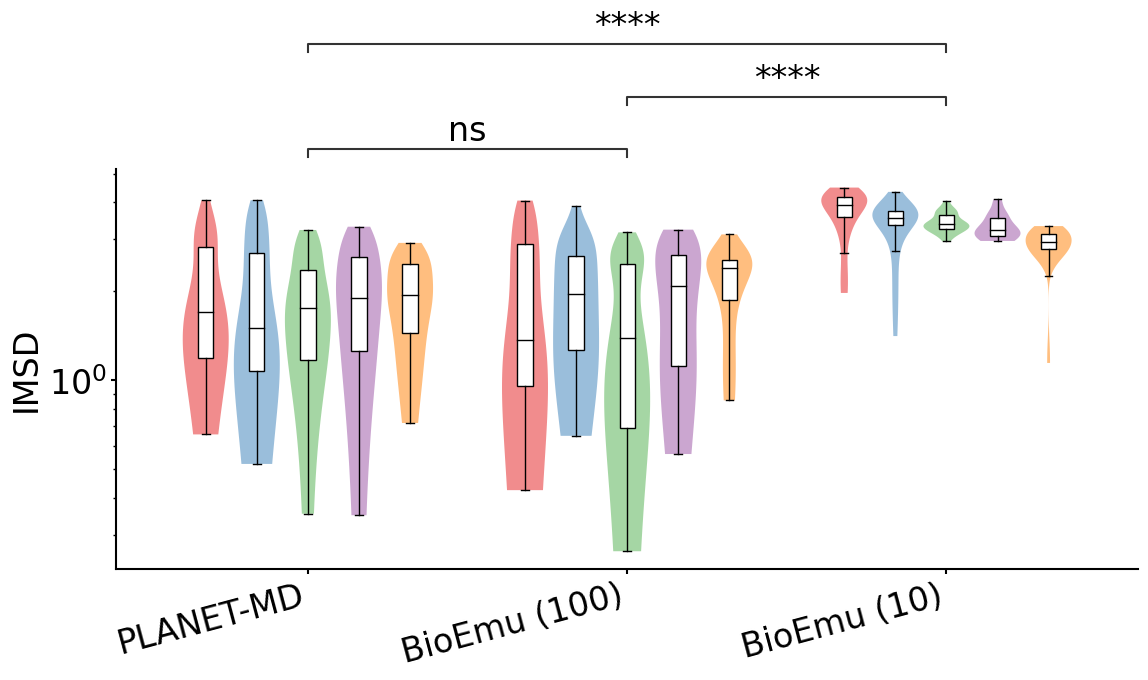

IMSD (violin)  PLANET-MD vs BioEmu (100): U=9598, p=7.454e-01, n=137 vs 137
IMSD (violin)  PLANET-MD vs BioEmu (10): U=1582, p=1.238e-32, n=137 vs 137
IMSD (violin)  BioEmu (100) vs BioEmu (10): U=1452, p=1.130e-33, n=137 vs 137


In [99]:
fig, ax = plt.subplots(figsize=FIG_WIDE)
_violin_box_hue(ax, imsd_df, "Method", "IMSD", "Size Group",
                order, size_group_order, size_palette)
ax.set_yscale("log")
ax.set_ylabel("IMSD")
ax.set_xlabel("")

pairs = list(combinations(order, 2))
annotator = Annotator(ax, pairs, data=imsd_df, x="Method", y="IMSD", order=order)
annotator.configure(test="Mann-Whitney", text_format="star", loc="outside", verbose=0)
annotator.apply_and_annotate()

finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig2d_imsd_by_size_violin.svg")
plt.show()

# ── Significance stats for caption ──────────────────────────────────────
from scipy.stats import mannwhitneyu as _mwu
for _a, _b in combinations(["PLANET-MD", "BioEmu (100)", "BioEmu (10)"], 2):
    _x = imsd_df.loc[imsd_df["Method"] == _a, "IMSD"].values
    _y = imsd_df.loc[imsd_df["Method"] == _b, "IMSD"].values
    _u, _p = _mwu(_x, _y, alternative="two-sided")
    print(f"IMSD (violin)  {_a} vs {_b}: U={_u:.0f}, p={_p:.3e}, n={len(_x)} vs {len(_y)}")


## Fig 3a — PlanetMD Predicted RMSF vs. hetNOE

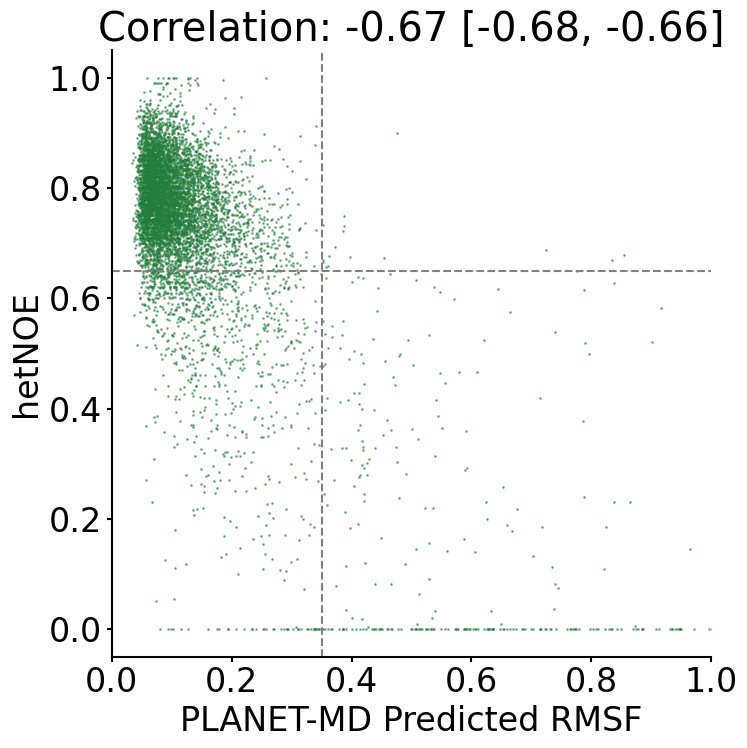

Binary classification (NOE≥0.65 / RMSF<0.35): accuracy=0.8688 (86.9%), N=8249
              precision    recall  f1-score   support

    flexible       0.94      0.23      0.37      1373
       rigid       0.87      1.00      0.93      6876

    accuracy                           0.87      8249
   macro avg       0.90      0.61      0.65      8249
weighted avg       0.88      0.87      0.83      8249



In [100]:
relaxdb_json_path = RELAXDB_ROOT / "RelaxDB_with_other_metrics_22jan2025.json"
with open(relaxdb_json_path) as f:
    rxdb = json.load(f)
relaxdb = pd.DataFrame.from_dict(rxdb)

rxdb_npz_dir = RELAXDB_ROOT / "rxdb_rocketshp_npz"
rxdb_rocketshp = {}
for npz_file in sorted(rxdb_npz_dir.glob("*.npz")):
    protein_id = npz_file.stem
    data = np.load(npz_file, allow_pickle=False)
    rxdb_rocketshp[protein_id] = {k: data[k] for k in data.files}

rmsf_all, noe_all = [], []
for protein_id in rxdb_rocketshp:
    if protein_id not in relaxdb.index:
        continue
    rmsf_all.append(rxdb_rocketshp[protein_id]["rmsf"])
    noe_all.append(relaxdb.loc[protein_id, "NOE"])

rmsf_flat = np.concatenate(rmsf_all)
noe_flat = np.concatenate(noe_all)

rmsf_nonan, noe_nonan = zip(*[
    (r, n) for r, n in zip(rmsf_flat, noe_flat) if n is not None
])
rmsf_nonan, noe_nonan = list(rmsf_nonan), list(noe_nonan)

result = pearsonr(rmsf_nonan, noe_nonan)
correlation, pval = result[0], result[1]
ci = result.confidence_interval()

fig, ax = plt.subplots(figsize=FIG_SQUARE)
ax.scatter(rmsf_nonan, noe_nonan, s=1, alpha=0.5, color=COLORS["PLANET-MD"])
ax.axhline(y=0.65, color="gray", linestyle="--")
ax.axvline(x=0.35, color="gray", linestyle="--")
ax.set_xlabel("PLANET-MD Predicted RMSF")
ax.set_xlim(0, 1)
ax.set_ylabel("hetNOE")
ax.set_title(f"Correlation: {correlation:.2f} [{ci[0]:.2f}, {ci[1]:.2f}]")
finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig3a_hetnoe_scatter.svg")
plt.show()

# ── Binary classification accuracy (rigid vs flexible) ───────────────────
# Sign flip: low RMSF <-> high hetNOE (rigid)
_NOE_THRESH  = 0.65
_RMSF_THRESH = 0.35
_noe_label  = (np.array(noe_nonan, dtype=float) >= _NOE_THRESH).astype(int)
_rmsf_label = (np.array(rmsf_nonan) < _RMSF_THRESH).astype(int)
_acc = (_noe_label == _rmsf_label).mean()
print(f"Binary classification (NOE≥{_NOE_THRESH} / RMSF<{_RMSF_THRESH}): "
      f"accuracy={_acc:.4f} ({_acc*100:.1f}%), N={len(_noe_label)}")
from sklearn.metrics import classification_report
print(classification_report(_noe_label, _rmsf_label, target_names=["flexible", "rigid"]))


## Fig 3b — ACRIIA4: ReLU(1 - RMSF) vs. hetNOE

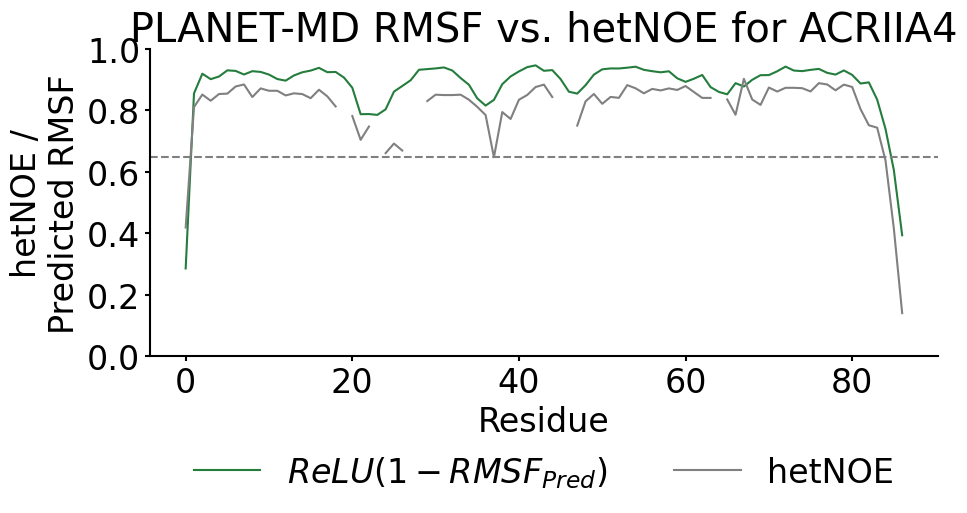

In [101]:
protein_id = "ACRIIA4"
rmsf_pred = rxdb_rocketshp[protein_id]["rmsf"]
noe = relaxdb.loc[protein_id, "NOE"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    relu(torch.from_numpy(1 - rmsf_pred)).numpy(),
    label="$ReLU(1 - RMSF_{Pred})$",
    color=COLORS["PLANET-MD"],
)
ax.plot(noe, label="hetNOE", color="gray")
ax.axhline(y=0.65, color="gray", linestyle="--")
ax.set_xlabel("Residue")
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylabel("hetNOE /\nPredicted RMSF")
ax.set_title(f"PLANET-MD RMSF vs. hetNOE for {protein_id}")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2)
finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig3b_acriia4_lineplot.svg")
plt.show()

## Fig 4a — Temperature dependence: RMSE

/tmp/ipykernel_978849/3058770655.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.boxplot(


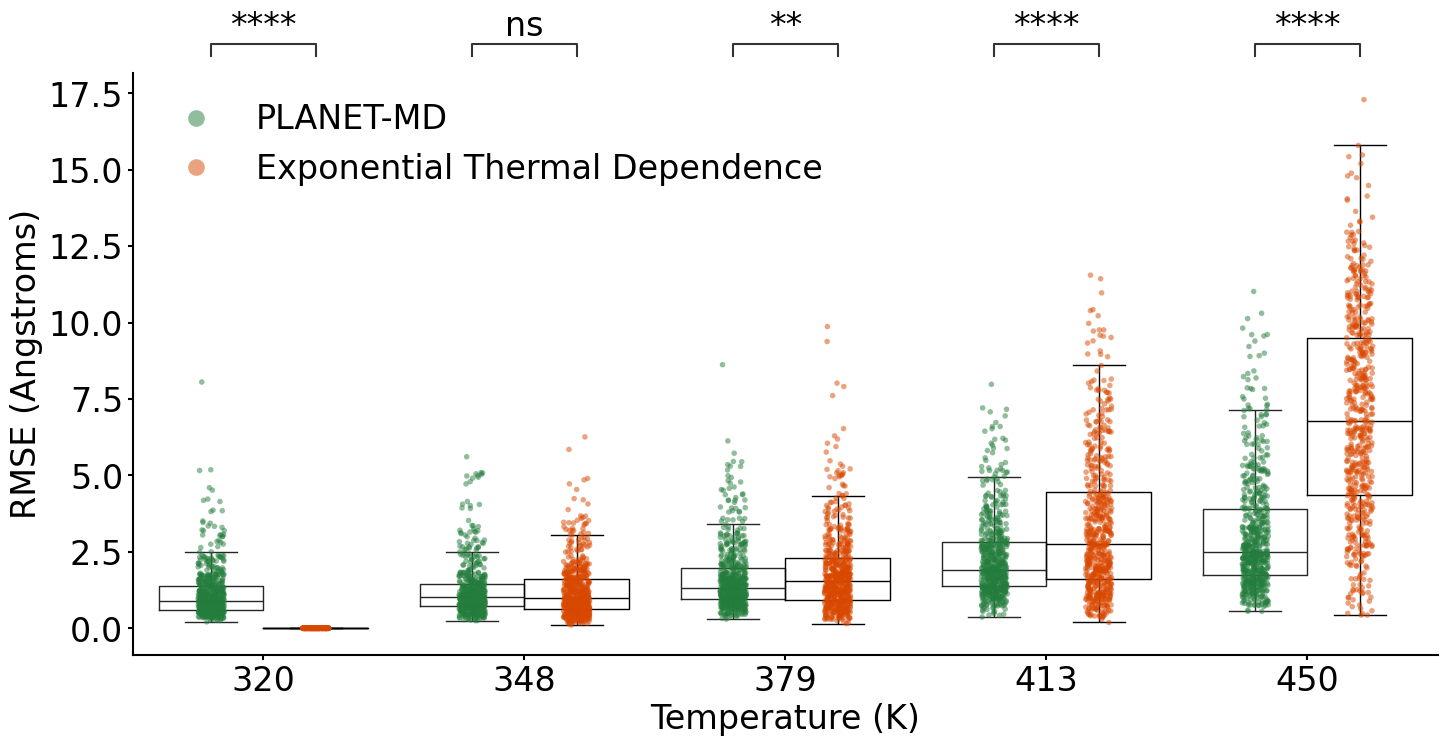

RMSE  T=320K  PLANET-MD vs Exponential Thermal Dependence: U=386884, p=1.081e-233, n=622 vs 622
RMSE  T=348K  PLANET-MD vs Exponential Thermal Dependence: U=198336, p=4.399e-01, n=622 vs 622
RMSE  T=379K  PLANET-MD vs Exponential Thermal Dependence: U=176480, p=7.424e-03, n=622 vs 622
RMSE  T=413K  PLANET-MD vs Exponential Thermal Dependence: U=143334, p=2.596e-15, n=622 vs 622
RMSE  T=450K  PLANET-MD vs Exponential Thermal Dependence: U=61441, p=2.090e-96, n=622 vs 622


In [102]:
temp_df = pd.read_csv(MDCATH_PRECOMPUTED / "temperature_joint_results.csv")
temp_df["rmse"] = temp_df["rmse"] * 10  # nm → Å
method_order = ["PLANET-MD", "Exponential Thermal Dependence"]
palette_temp = [COLORS[m] for m in method_order]
temp_order = [str(t) for t in sorted(temp_df["temperature"].unique())]
temp_df["temperature"] = temp_df["temperature"].astype(str)

fig, ax = plt.subplots(figsize=(15, 8))
sns.boxplot(
    x="temperature", y="rmse", hue="method",
    hue_order=method_order, order=temp_order,
    data=temp_df, fill=False, fliersize=0, linewidth=1, legend=False, color="black",
)
sns.stripplot(
    x="temperature", y="rmse", hue="method",
    hue_order=method_order, order=temp_order,
    data=temp_df, dodge=True, alpha=0.5, size=4, palette=palette_temp,
)
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("RMSE (Angstroms)")
ax.legend()

pairs = [((t, method_order[0]), (t, method_order[1])) for t in temp_order]
annotator = Annotator(ax, pairs, data=temp_df, x="temperature", y="rmse",
                      hue="method", hue_order=method_order, order=temp_order)
annotator.configure(test="Mann-Whitney", text_format="star", loc="outside", verbose=0)
annotator.apply_and_annotate()

finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig4a_temperature_rmse.svg", bbox_inches="tight", transparent=True)
plt.show()

# ── Significance stats for caption ──────────────────────────────────────
from scipy.stats import mannwhitneyu as _mwu
for _t in temp_order:
    _x = temp_df.loc[(temp_df["temperature"] == _t) & (temp_df["method"] == method_order[0]), "rmse"].values
    _y = temp_df.loc[(temp_df["temperature"] == _t) & (temp_df["method"] == method_order[1]), "rmse"].values
    _u, _p = _mwu(_x, _y, alternative="two-sided")
    print(f"RMSE  T={_t}K  {method_order[0]} vs {method_order[1]}: U={_u:.0f}, p={_p:.3e}, n={len(_x)} vs {len(_y)}")


## Fig 4a (violin) — Temperature dependence: RMSE

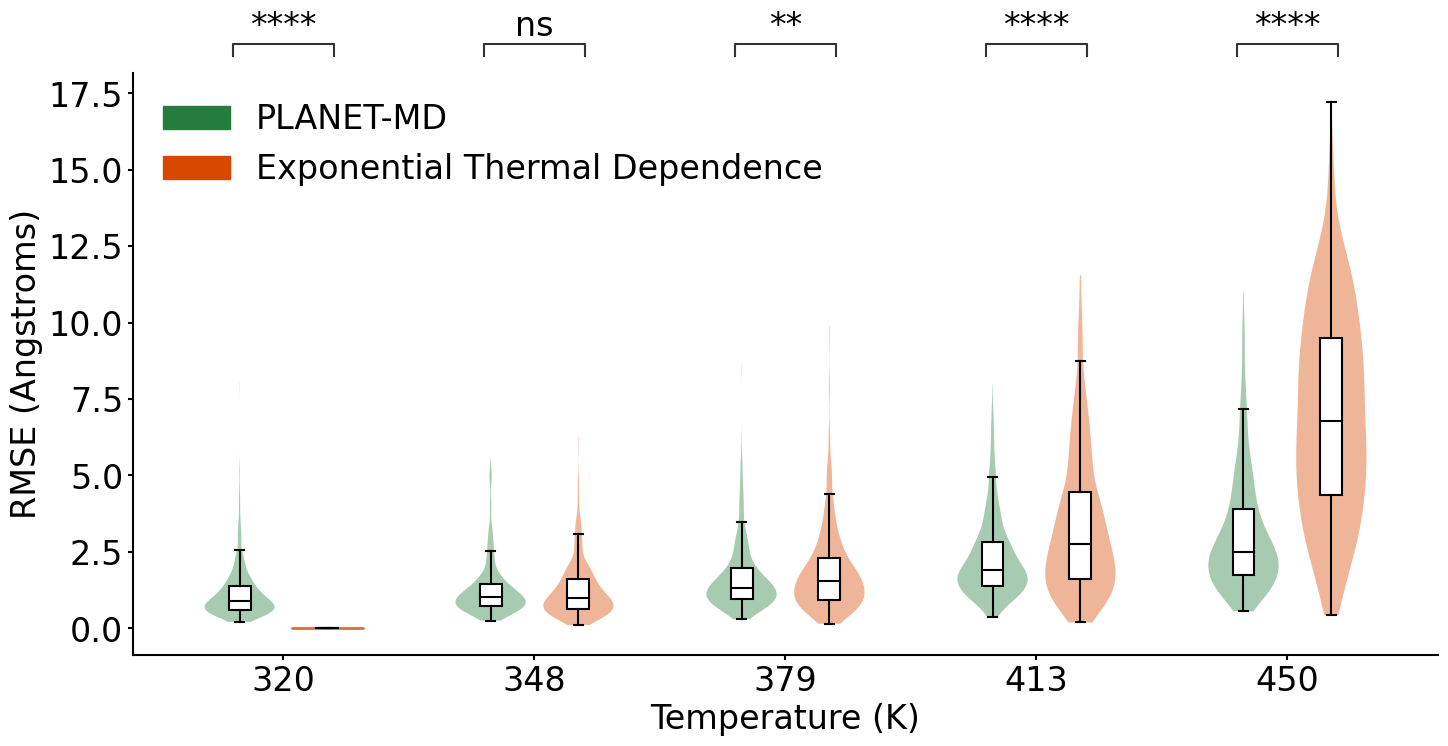

RMSE (violin)  T=320K  PLANET-MD vs Exponential Thermal Dependence: U=386884, p=1.081e-233, n=622 vs 622
RMSE (violin)  T=348K  PLANET-MD vs Exponential Thermal Dependence: U=198336, p=4.399e-01, n=622 vs 622
RMSE (violin)  T=379K  PLANET-MD vs Exponential Thermal Dependence: U=176480, p=7.424e-03, n=622 vs 622
RMSE (violin)  T=413K  PLANET-MD vs Exponential Thermal Dependence: U=143334, p=2.596e-15, n=622 vs 622
RMSE (violin)  T=450K  PLANET-MD vs Exponential Thermal Dependence: U=61441, p=2.090e-96, n=622 vs 622


In [103]:
def _violin_box_plot(ax, temp_df, y_col, method_order, temp_order, palette_temp):
    """Draw aligned violin + box plots using explicit matplotlib positions."""
    half_width = 0.35          # total hue group width per temperature tick
    box_width = 0.25           # box width relative to group
    violin_width = 0.8         # violin width relative to half_width

    offsets = [-half_width / 2, half_width / 2]  # one per method

    for mi, (method, color) in enumerate(zip(method_order, palette_temp)):
        offset = offsets[mi]
        for ti, temp in enumerate(temp_order):
            vals = temp_df.loc[
                (temp_df["method"] == method) & (temp_df["temperature"] == temp), y_col
            ].dropna().values

            x_center = ti + offset

            # --- violin ---
            std = vals.std()
            if std < 1e-9:
                # degenerate: draw a horizontal tick instead
                ax.plot(
                    [x_center - half_width * violin_width / 2,
                     x_center + half_width * violin_width / 2],
                    [vals[0], vals[0]],
                    color=color, linewidth=2, alpha=0.8, solid_capstyle="round",
                )
            else:
                vp = ax.violinplot(
                    vals, positions=[x_center],
                    widths=half_width * violin_width,
                    showmeans=False, showmedians=False, showextrema=False,
                )
                for body in vp["bodies"]:
                    body.set_facecolor(color)
                    body.set_alpha(0.4)
                    body.set_edgecolor("none")

            # --- box ---
            q1, med, q3 = np.percentile(vals, [25, 50, 75])
            iqr = q3 - q1
            lo_whisker = max(vals.min(), q1 - 1.5 * iqr)
            hi_whisker = min(vals.max(), q3 + 1.5 * iqr)
            bw = half_width * box_width
            rect = mpatches.FancyBboxPatch(
                (x_center - bw / 2, q1), bw, iqr,
                boxstyle="square,pad=0",
                linewidth=1.5, edgecolor="black", facecolor="white", zorder=3,
            )
            ax.add_patch(rect)
            ax.plot([x_center - bw / 2, x_center + bw / 2], [med, med],
                    color="black", linewidth=1.5, zorder=4)
            ax.plot([x_center, x_center], [q1, lo_whisker],
                    color="black", linewidth=1.5, zorder=3)
            ax.plot([x_center, x_center], [q3, hi_whisker],
                    color="black", linewidth=1.5, zorder=3)
            cap_w = bw * 0.4
            for cap_y in [lo_whisker, hi_whisker]:
                ax.plot([x_center - cap_w / 2, x_center + cap_w / 2],
                        [cap_y, cap_y], color="black", linewidth=1.5, zorder=3)

    ax.set_xticks(range(len(temp_order)))
    ax.set_xticklabels(temp_order)
    ax.set_xlim(-0.6, len(temp_order) - 0.4)


fig, ax = plt.subplots(figsize=(15, 8))
_violin_box_plot(ax, temp_df, "rmse", method_order, temp_order, palette_temp)
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("RMSE (Angstroms)")

handles = [mpatches.Patch(color=c, label=m) for m, c in zip(method_order, palette_temp)]
ax.legend(handles=handles)

pairs = [((t, method_order[0]), (t, method_order[1])) for t in temp_order]
annotator = Annotator(ax, pairs, data=temp_df, x="temperature", y="rmse",
                      hue="method", hue_order=method_order, order=temp_order)
annotator.configure(test="Mann-Whitney", text_format="star", loc="outside", verbose=0)
annotator.apply_and_annotate()

finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig4a_temperature_rmse_violin.svg", bbox_inches="tight", transparent=True)
plt.show()

# ── Significance stats for caption ──────────────────────────────────────
from scipy.stats import mannwhitneyu as _mwu
for _t in temp_order:
    _x = temp_df.loc[(temp_df["temperature"] == _t) & (temp_df["method"] == method_order[0]), "rmse"].values
    _y = temp_df.loc[(temp_df["temperature"] == _t) & (temp_df["method"] == method_order[1]), "rmse"].values
    _u, _p = _mwu(_x, _y, alternative="two-sided")
    print(f"RMSE (violin)  T={_t}K  {method_order[0]} vs {method_order[1]}: U={_u:.0f}, p={_p:.3e}, n={len(_x)} vs {len(_y)}")


## Fig 4b — Temperature dependence: Spearman correlation

/tmp/ipykernel_978849/1807304598.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.boxplot(


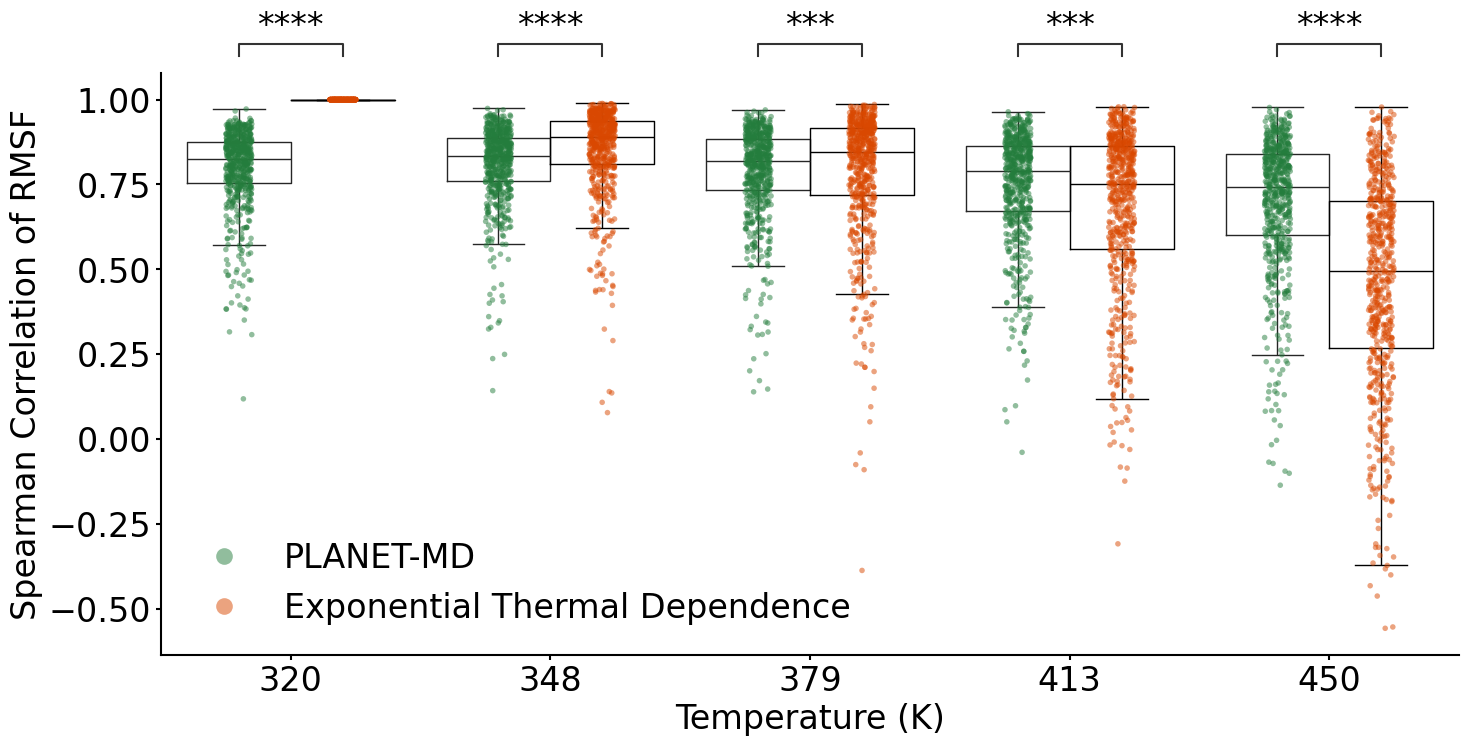

Spearman  T=320K  PLANET-MD vs Exponential Thermal Dependence: U=0, p=1.045e-226, n=622 vs 622
Spearman  T=348K  PLANET-MD vs Exponential Thermal Dependence: U=133907, p=5.620e-21, n=622 vs 622
Spearman  T=379K  PLANET-MD vs Exponential Thermal Dependence: U=171716, p=6.057e-04, n=622 vs 622
Spearman  T=413K  PLANET-MD vs Exponential Thermal Dependence: U=216285, p=3.116e-04, n=622 vs 622
Spearman  T=450K  PLANET-MD vs Exponential Thermal Dependence: U=286424, p=9.165e-49, n=622 vs 622


In [104]:
fig, ax = plt.subplots(figsize=(15, 8))
sns.boxplot(
    x="temperature", y="spearman_stat", hue="method",
    hue_order=method_order, order=temp_order,
    data=temp_df, fill=False, fliersize=0, linewidth=1, legend=False, color="black",
)
sns.stripplot(
    x="temperature", y="spearman_stat", hue="method",
    hue_order=method_order, order=temp_order,
    data=temp_df, dodge=True, alpha=0.5, size=4, palette=palette_temp,
)
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Spearman Correlation of RMSF")
ax.legend()

pairs = [((t, method_order[0]), (t, method_order[1])) for t in temp_order]
annotator = Annotator(ax, pairs, data=temp_df, x="temperature", y="spearman_stat",
                      hue="method", hue_order=method_order, order=temp_order)
annotator.configure(test="Mann-Whitney", text_format="star", loc="outside", verbose=0)
annotator.apply_and_annotate()

finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig4b_temperature_spearman.svg", bbox_inches="tight", transparent=True)
plt.show()

# ── Significance stats for caption ──────────────────────────────────────
from scipy.stats import mannwhitneyu as _mwu
for _t in temp_order:
    _x = temp_df.loc[(temp_df["temperature"] == _t) & (temp_df["method"] == method_order[0]), "spearman_stat"].values
    _y = temp_df.loc[(temp_df["temperature"] == _t) & (temp_df["method"] == method_order[1]), "spearman_stat"].values
    _u, _p = _mwu(_x, _y, alternative="two-sided")
    print(f"Spearman  T={_t}K  {method_order[0]} vs {method_order[1]}: U={_u:.0f}, p={_p:.3e}, n={len(_x)} vs {len(_y)}")


## Fig 4b (violin) — Temperature dependence: Spearman correlation

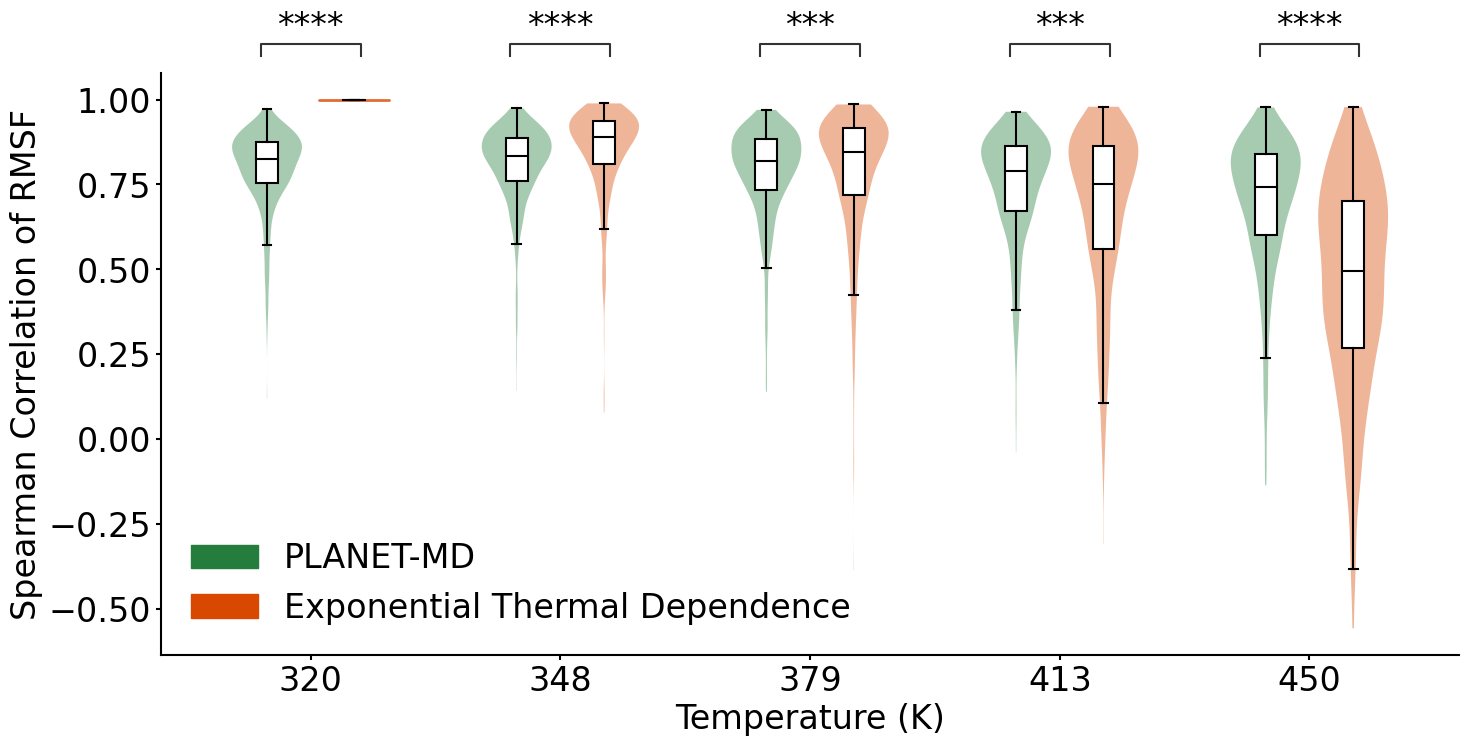

In [15]:
fig, ax = plt.subplots(figsize=(15, 8))
_violin_box_plot(ax, temp_df, "spearman_stat", method_order, temp_order, palette_temp)
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Spearman Correlation of RMSF")

handles = [mpatches.Patch(color=c, label=m) for m, c in zip(method_order, palette_temp)]
ax.legend(handles=handles)

pairs = [((t, method_order[0]), (t, method_order[1])) for t in temp_order]
annotator = Annotator(ax, pairs, data=temp_df, x="temperature", y="spearman_stat",
                      hue="method", hue_order=method_order, order=temp_order)
annotator.configure(test="Mann-Whitney", text_format="star", loc="outside", verbose=0)
annotator.apply_and_annotate()

finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig4b_temperature_spearman_violin.svg", bbox_inches="tight", transparent=True)
plt.show()

# ── Significance stats for caption ──────────────────────────────────────
from scipy.stats import mannwhitneyu as _mwu
for _t in temp_order:
    _x = temp_df.loc[(temp_df["temperature"] == _t) & (temp_df["method"] == method_order[0]), "spearman_stat"].values
    _y = temp_df.loc[(temp_df["temperature"] == _t) & (temp_df["method"] == method_order[1]), "spearman_stat"].values
    _u, _p = _mwu(_x, _y, alternative="two-sided")
    print(f"Spearman (violin)  T={_t}K  {method_order[0]} vs {method_order[1]}: U={_u:.0f}, p={_p:.3e}, n={len(_x)} vs {len(_y)}")


## Fig 4d — Glutaminase (1u60A00) RMSF at each temperature

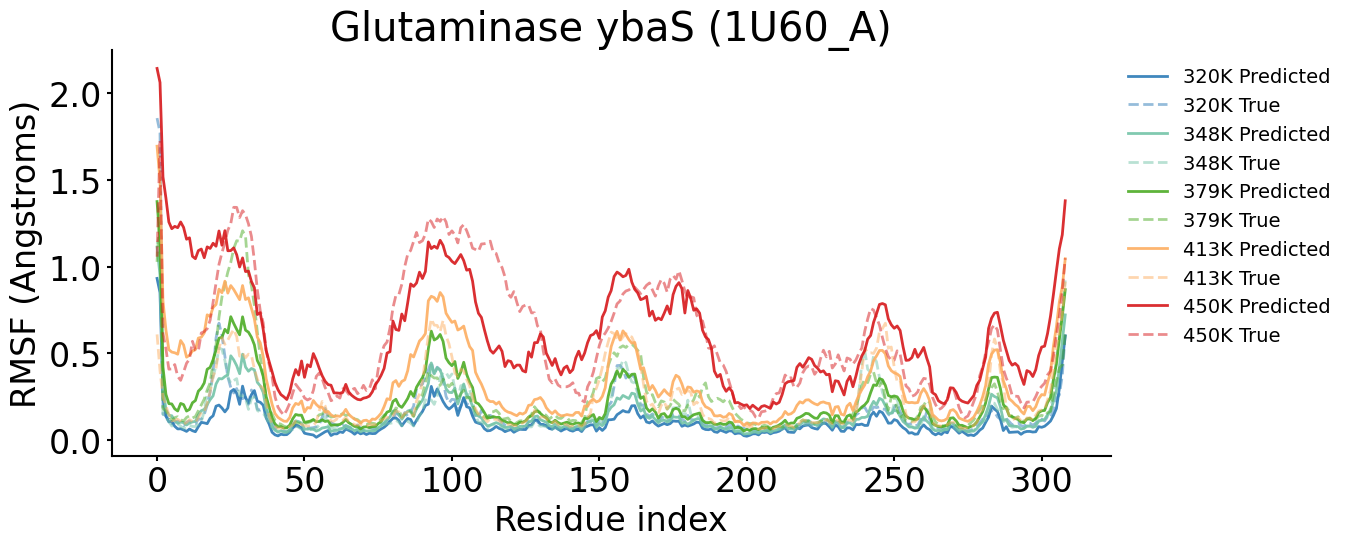

In [16]:
case_data = np.load(MDCATH_PRECOMPUTED / "temperature_case_study.npz")
# Cool -> warm palette; mid-tone green avoids the near-white yellow of RdYlBu
color_list = ["#2c7bb6", "#74c4a8", "#4dac26", "#fdae61", "#d7191c"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, temp in enumerate(TEMP_LIST):
    c = color_list[i]
    ax.plot(case_data[f"rshp_{temp}"], c=c, linewidth=2, alpha=0.9,
            label=f"{temp}K Predicted")
    ax.plot(case_data[f"ref_{temp}"],  c=c, linewidth=2, alpha=0.5,
            linestyle="--", label=f"{temp}K True")

ax.set_xlabel("Residue index")
ax.set_ylabel("RMSF (Angstroms)")
ax.set_title("Glutaminase ybaS (1U60_A)")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), frameon=False, fontsize=14)
finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig4d_glutaminase_temperature.svg", bbox_inches="tight", transparent=True)
plt.show()

## Fig 5a — KRAS GCC-LMI networks (by residue index and by cluster)

In [17]:
kras_seq = "MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVIDGETCLLDILDTAGQEEYSAMRDQYMRTGEGFLCVFAINNTKSFEDIHHYREQIKRVKDSEDVPMVLVGNKCDLPSRTVDTKQAQDLARSYGIPFIETSAKTRQRVEDAFYTLVREIRQYRLKKISKEEKTPGCVKIKKCIIM"


def residue_range_to_seq(seq, rng):
    start, end = rng
    return seq[start-1:end+1]

p_loop = (10, 14)
switch_i = (30, 39)
switch_ii = (58, 71)
hvr = (167, 188)

print(residue_range_to_seq(kras_seq, p_loop))
print(residue_range_to_seq(kras_seq, switch_i))
print(residue_range_to_seq(kras_seq, switch_ii))
print(residue_range_to_seq(kras_seq, hvr))

GAGGVG
DEYDPTIEDSY
TAGQEEYSAMRDQYM
RLKKISKEEKTPGCVKIKKCIIM


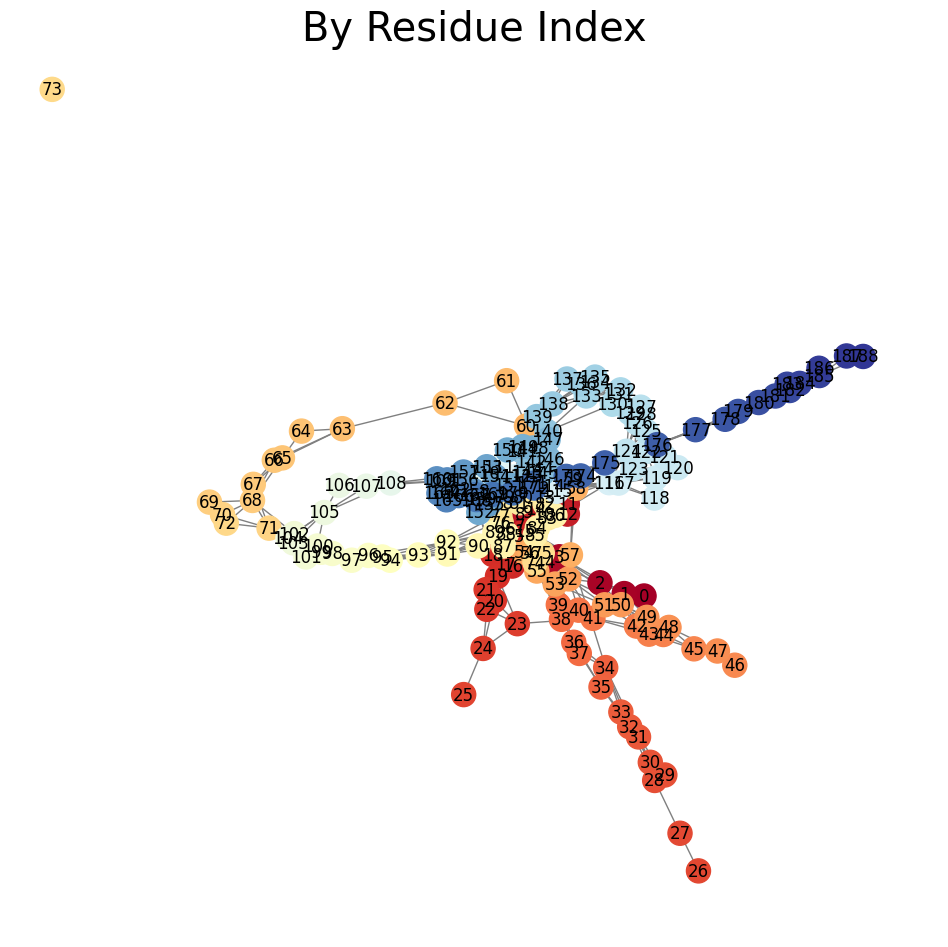

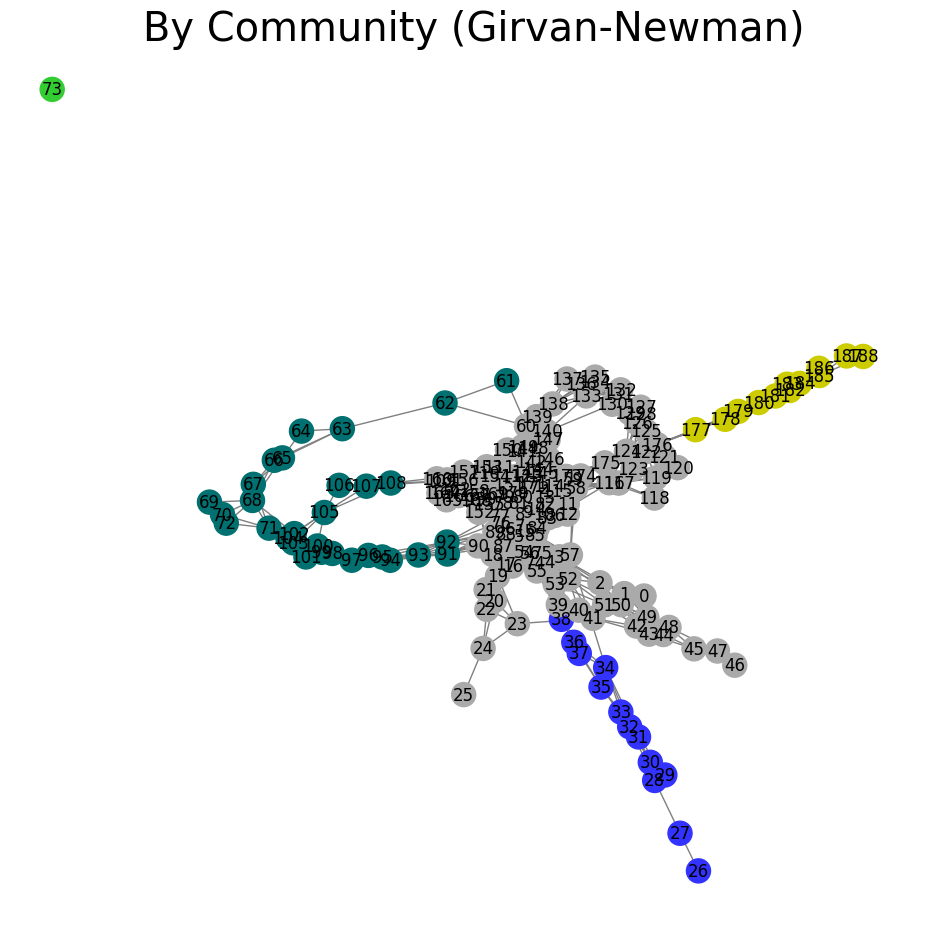

In [18]:
# ── Load precomputed ───────────────────────────────────────────────────────
_net_data   = np.load(KRAS_PRECOMPUTED / "kras_wt_masked_network.npz")
masked_net  = _net_data["masked_net"]
gcc_network = _net_data["gcc_network"]

with open(KRAS_PRECOMPUTED / "kras_gcc_lmi_clusters.json") as f:
    clusts = [tuple(c) for c in json.load(f)]

NETWORK_PRED_THRESH = 0.5
NETWORK_PLOT_SEED   = 0

# Cluster colors: C1=gray, C2=blue (Switch I), C3=teal (Switch II),
#                 C4=green (single residue), C5=yellow (HVR)
PYMOL_CLUSTER_COLORS = [
    "#aaaaaa",   # C1 — gray
    "#3333ff",   # C2 — blue  (Switch I)
    "#007070",   # C3 — teal  (Switch II)
    "#33cc33",   # C4 — green
    "#cccc00",   # C5 — yellow (HVR)
]

node_cluster_colors = [PYMOL_CLUSTER_COLORS[0]] * masked_net.shape[0]
for i, cluster in enumerate(clusts):
    for node in cluster:
        node_cluster_colors[node] = PYMOL_CLUSTER_COLORS[i]

# ── By residue index ───────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
pairwise_correlation_to_network(
    masked_net, thresh=NETWORK_PRED_THRESH,
    title="By Residue Index", seed=NETWORK_PLOT_SEED, ax=ax,
)
finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig5a_kras_network_by_residue.svg")
plt.show()

# ── By community (Girvan-Newman) ───────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
display_network(
    masked_net, title="By Community (Girvan-Newman)",
    node_color=node_cluster_colors, edge_color="gray",
    seed=NETWORK_PLOT_SEED, ax=ax,
)
finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig5a_kras_network_by_cluster.svg")
plt.show()

## Fig 5b — KRAS betweenness centrality (DMS)

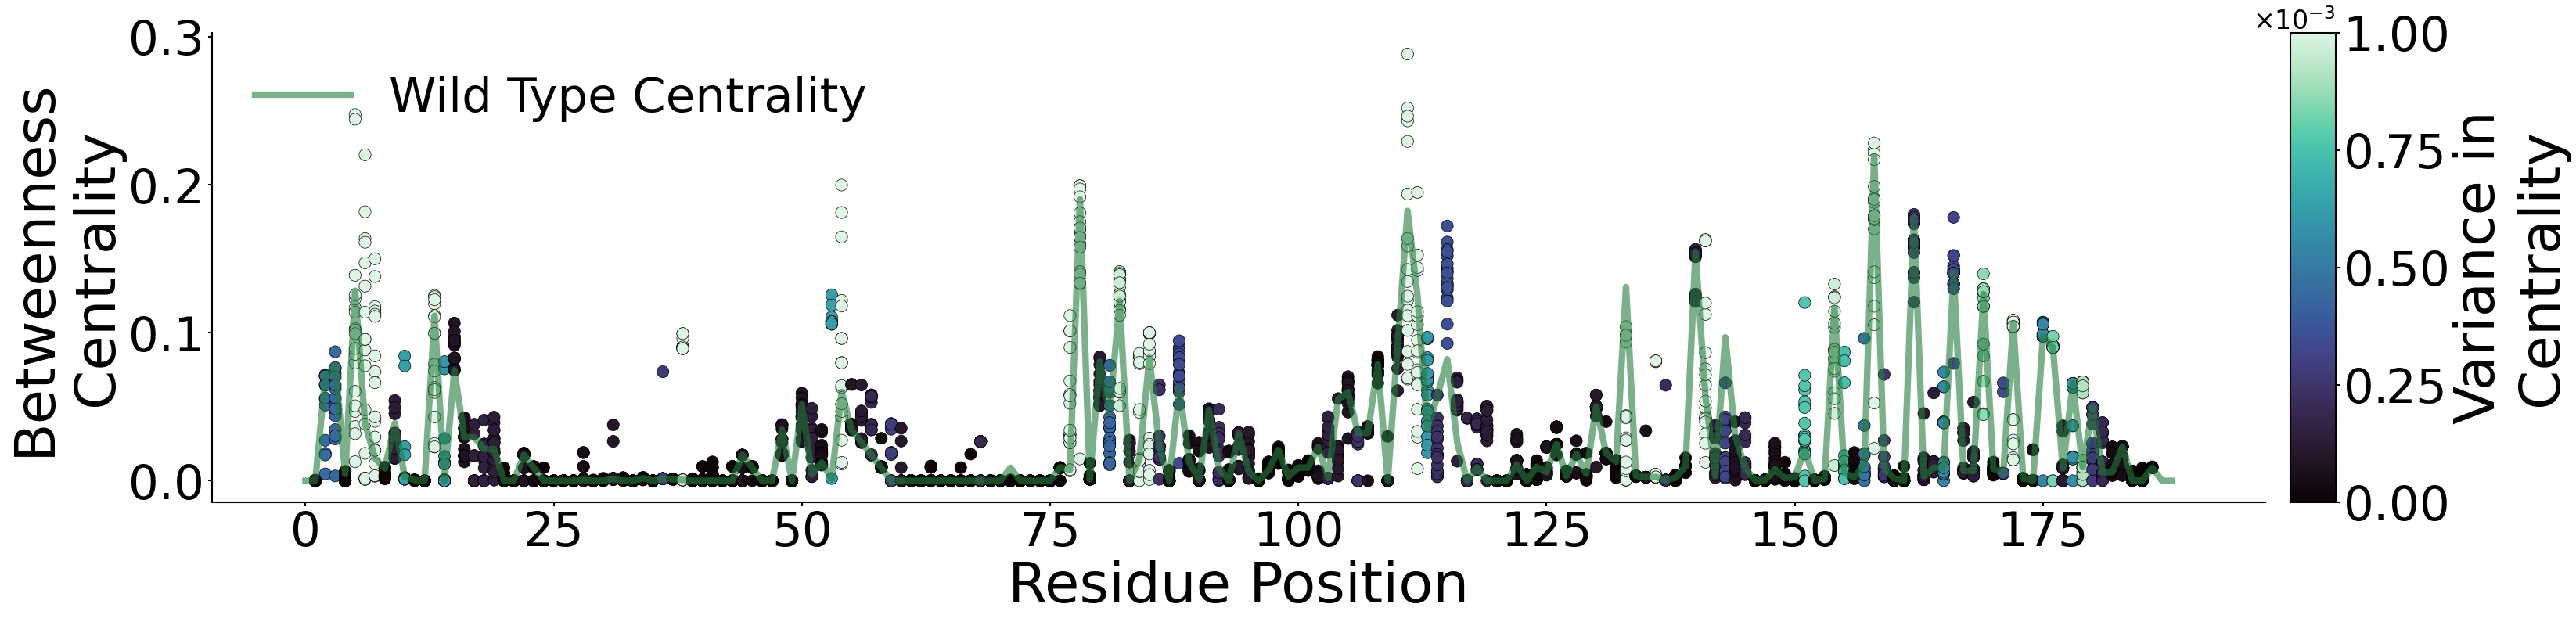

In [ ]:
res_df = pd.read_csv(KRAS_PRECOMPUTED / "kras_res_df.csv")
with open(KRAS_PRECOMPUTED / "kras_wild_type_centrality.json") as f:
    wt_centrality = {int(k): v for k, v in json.load(f).items()}

LINEWIDTH = 0.5
POINT_SIZE = 120
FIG5_FONT = 52

# Fixed layout: plot occupies [left, bottom, plot_w, height] in figure fraction,
# colorbar is a fixed-width strip to its right with a fixed gap.
FIG5_W, FIG5_H = 32, 8
CBAR_GAP  = 0.01   # gap between plot and cbar, in figure fraction
CBAR_W    = 0.018  # colorbar width in figure fraction
PLOT_LEFT = 0.07
PLOT_BOT  = 0.15
PLOT_W    = 0.82   # same for both fig5a and fig5b
PLOT_H    = 0.75

def _make_fig5(figsize=(FIG5_W, FIG5_H)):
    fig = plt.figure(figsize=figsize)
    ax  = fig.add_axes([PLOT_LEFT, PLOT_BOT, PLOT_W, PLOT_H])
    cax = fig.add_axes([PLOT_LEFT + PLOT_W + CBAR_GAP, PLOT_BOT, CBAR_W, PLOT_H])
    return fig, ax, cax

def _fill_cbar(cax, label, cmap, vmin, vmax):
    from matplotlib.ticker import ScalarFormatter
    norm = plt.Normalize(vmin, vmax)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=cax)
    cbar.set_label(label, fontsize=FIG5_FONT)
    cbar.ax.tick_params(labelsize=FIG5_FONT - 8, colors="black")
    cbar.outline.set_edgecolor("black")
    cbar.outline.set_linewidth(1.5)
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_scientific(True)
    fmt.set_powerlimits((0, 0))
    cbar.formatter = fmt
    cbar.update_ticks()

fig, ax, cax = _make_fig5()
sns.scatterplot(
    data=res_df, x="pos_i", y="centrality",
    hue="variance_centrality", palette="mako", hue_norm=(0, 1e-3),
    edgecolor="black", linewidth=LINEWIDTH, alpha=1.0,
    ax=ax, legend=False, s=POINT_SIZE,
)
_fill_cbar(cax, "Variance in\nCentrality", "mako", 0, 1e-3)
sns.lineplot(
    x=list(wt_centrality.keys()),
    y=list(wt_centrality.values()),
    ax=ax, label="Wild Type Centrality",
    color=COLORS["PLANET-MD"], linewidth=6, alpha=0.6,
)
ax.set_xlabel("Residue Position", fontsize=FIG5_FONT)
ax.set_ylabel("Betweenness\nCentrality", fontsize=FIG5_FONT)
ax.tick_params(axis="both", labelsize=FIG5_FONT - 8, width=1.5, colors="black")
ax.legend(loc="upper left", fontsize=FIG5_FONT - 8)
finalize(ax)
plt.savefig(SVG_DIR / "fig5b_kras_centrality.svg")
plt.show()

## Fig 5c — KRAS folding ΔΔG (DMS)

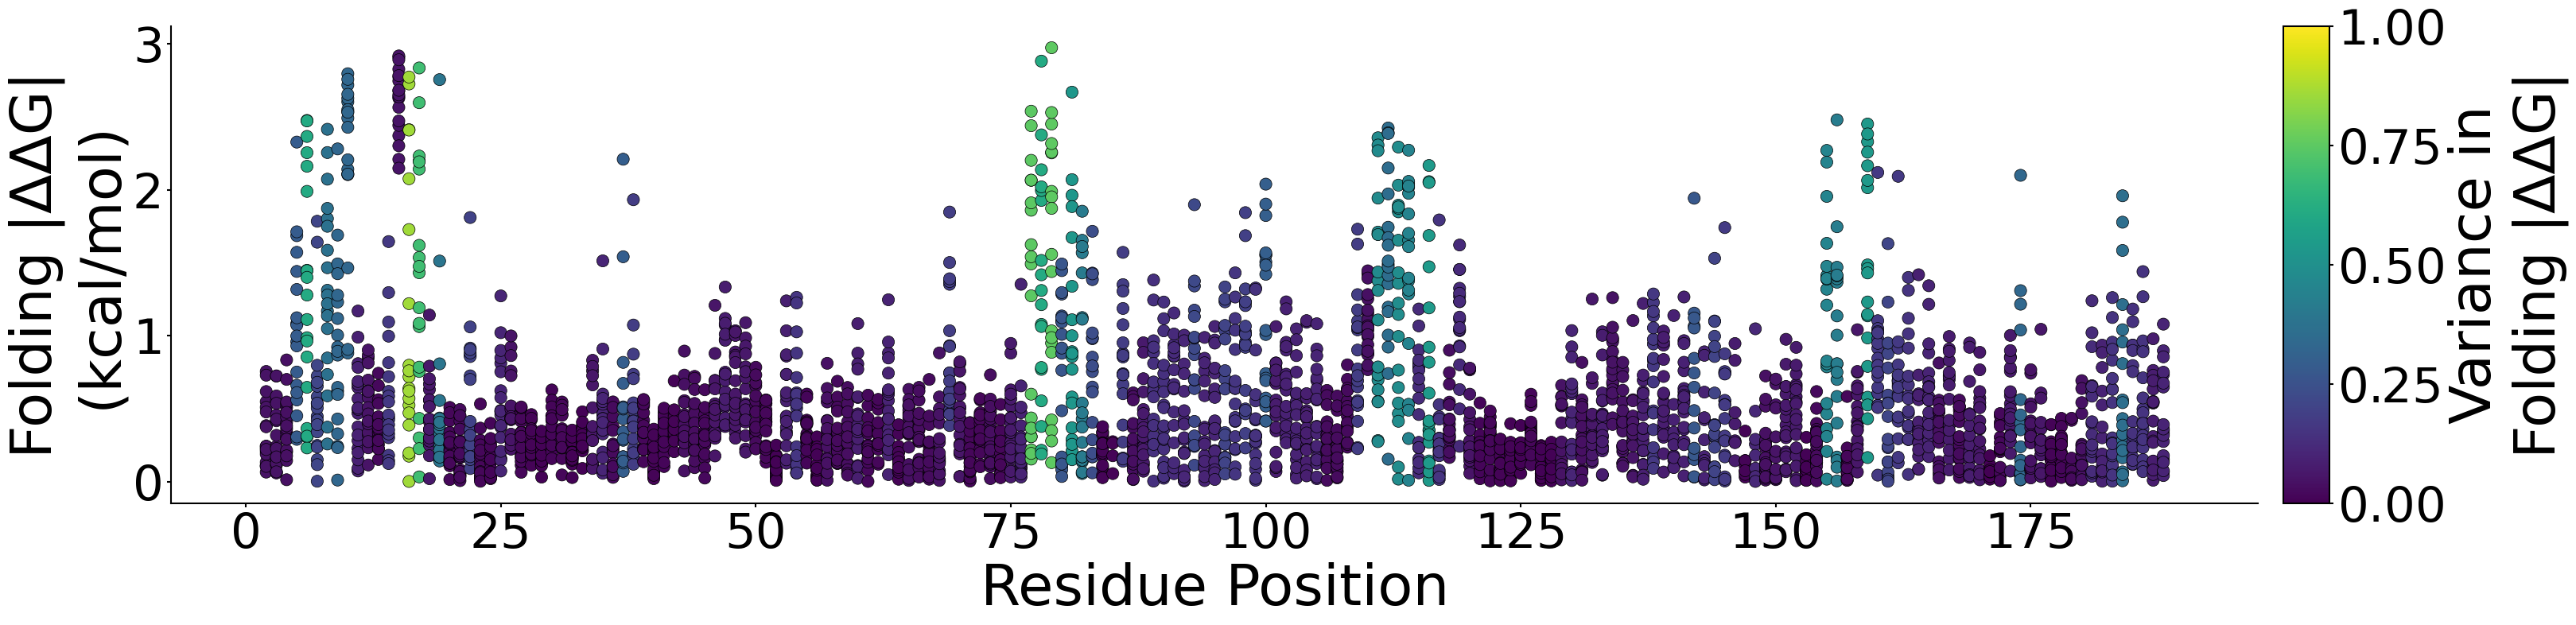

In [20]:
folding_ddg = pd.read_csv(KRAS_PRECOMPUTED / "kras_folding_ddg.csv")

fig, ax, cax = _make_fig5()
sns.scatterplot(
    data=folding_ddg, x="Pos_real", y="abs_mean_kcal/mol",
    hue="variance_kcal/mol", palette="viridis", hue_norm=(0, 1),
    edgecolor="black", linewidth=LINEWIDTH, alpha=1.0,
    ax=ax, legend=False, s=POINT_SIZE,
)
_fill_cbar(cax, "Variance in\nFolding |ΔΔG|", "viridis", 0, 1)
ax.set_xlabel("Residue Position", fontsize=FIG5_FONT)
ax.set_ylabel("Folding |ΔΔG|\n(kcal/mol)", fontsize=FIG5_FONT)
ax.tick_params(axis="both", labelsize=FIG5_FONT - 8, width=1.5, colors="black")
finalize(ax)
plt.savefig(SVG_DIR / "fig5c_kras_folding_ddg.svg")
plt.show()

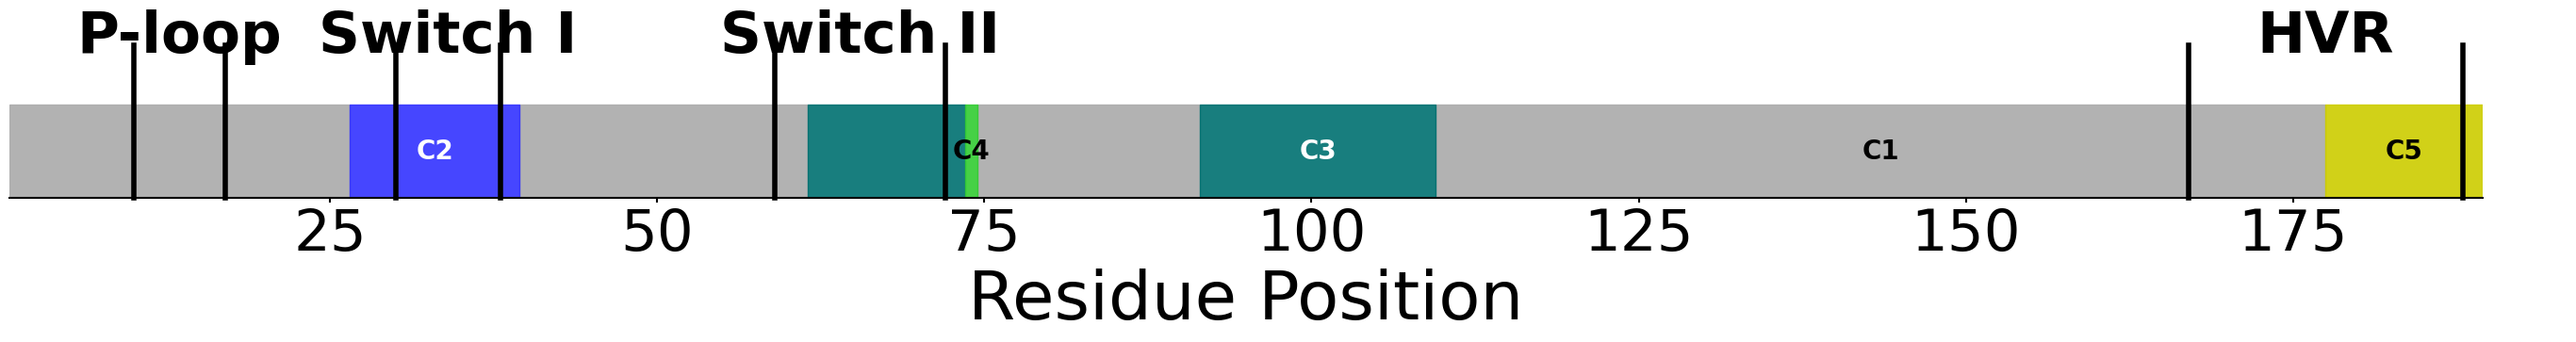

In [77]:
# ── Fig 5a: cluster spans + annotation tick-lines below DMS plots ──────────
# One row: cluster colored spans, with region annotations as vertical tick
# lines that protrude above the spans, labelled in between.

_PLOOP_COLOR    = "#d94801"
_SWICHI_COLOR   = "#3333ff"
_SWITCHII_COLOR = "#007070"
_HVR_COLOR      = "#cccc00"

REGION_ANNOTATIONS = [
    ("P-loop",    (10, 17)),
    ("Switch I",  (30, 38)),
    ("Switch II", (59, 72)),
    ("HVR",       (167, 188)),
]

CLUSTER_COLORS = [
    "#aaaaaa",       # C1 — gray
    _SWICHI_COLOR,   # C2 — blue  (Switch I)
    _SWITCHII_COLOR, # C3 — teal  (Switch II)
    "#33cc33",       # C4 — green
    _HVR_COLOR,      # C5 — yellow (HVR)
]

# Truncated gray_r: white at 0, medium gray at 1 (avoids pure black)
from matplotlib.colors import LinearSegmentedColormap as _LSC

_light_gray = _LSC.from_list("light_gray", plt.cm.gray_r(np.linspace(0, 0.65, 256)))

n_residues = masked_net.shape[0]
k = len(clusts)

def _get_spans(nodes_0based):
    nodes = sorted(int(n) + 1 for n in nodes_0based)
    spans, start, prev = [], nodes[0], nodes[0]
    for r in nodes[1:]:
        if r - prev == 1:
            prev = r
        else:
            spans.append((start, prev))
            start = prev = r
    spans.append((start, prev))
    return spans

def _text_color(hex_color):
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    luminance = (0.299 * r + 0.587 * g + 0.114 * b) / 255
    return "white" if luminance < 0.55 else "black"

_SPAN_FONT  = 20
_LABEL_FONT = 20

# y-coordinate layout within [0, 1]:
#   0.0 – 0.55  cluster spans
#   0.55 – 1.0  annotation tick lines + labels
_SPAN_YMIN, _SPAN_YMAX = 0.0, 0.55
_TICK_LO,   _TICK_HI   = 0.45, 0.90   # tick lines straddle the boundary
_LABEL_Y                = 0.95         # text above the tick lines

_FIG_W = FIG5_W
_FIG_H = 2.5

fig = plt.figure(figsize=(_FIG_W, _FIG_H))
ax = fig.add_axes([PLOT_LEFT, 0.15, PLOT_W, 0.72])
ax_stub = fig.add_axes([PLOT_LEFT + PLOT_W + CBAR_GAP, 0.15,
                         CBAR_W, 0.72], frameon=False)
ax_stub.set_xticks([])
ax_stub.set_yticks([])

ax.set_xlim(0.5, n_residues + 0.5)
ax.set_ylim(0, 1)
ax.set_yticks([])
for spine in ("left", "top", "right"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_linewidth(1.5)

# ── Cluster spans ─────────────────────────────────────────────────────────
for i, cluster in enumerate(clusts):
    color = CLUSTER_COLORS[i]
    spans = _get_spans(cluster)
    for s, e in spans:
        ax.axvspan(s - 0.5, e + 0.5, ymin=_SPAN_YMIN, ymax=_SPAN_YMAX,
                   color=color, alpha=0.9)
    largest = max(spans, key=lambda se: se[1] - se[0])
    ax.text((largest[0] + largest[1]) / 2, _SPAN_YMAX / 2, f"C{i+1}",
            ha="center", va="center", fontsize=_SPAN_FONT,
            color=_text_color(color), fontweight="bold", clip_on=True)

# ── Region annotation tick lines + labels ────────────────────────────────
_tick_kw = dict(color="black", linewidth=4.0, clip_on=False)
for name, (start, end) in REGION_ANNOTATIONS:
    mid = (start + end) / 2
    # vertical lines at region boundaries
    ax.axvline(start, ymin=0, ymax=_TICK_HI, **_tick_kw)
    ax.axvline(end,   ymin=0, ymax=_TICK_HI, **_tick_kw)
    # label centred between the two lines
    ax.text(mid, _LABEL_Y, name, ha="center", va="center",
            fontsize=FIG5_FONT - 8, color="black", fontweight="bold", clip_on=False)

ax.set_xlabel("Residue Position", fontsize=FIG5_FONT)
ax.tick_params(axis="x", labelsize=FIG5_FONT - 8)

plt.savefig(SVG_DIR / "fig5a_kras_regions_vs_clusters.svg")
plt.show()


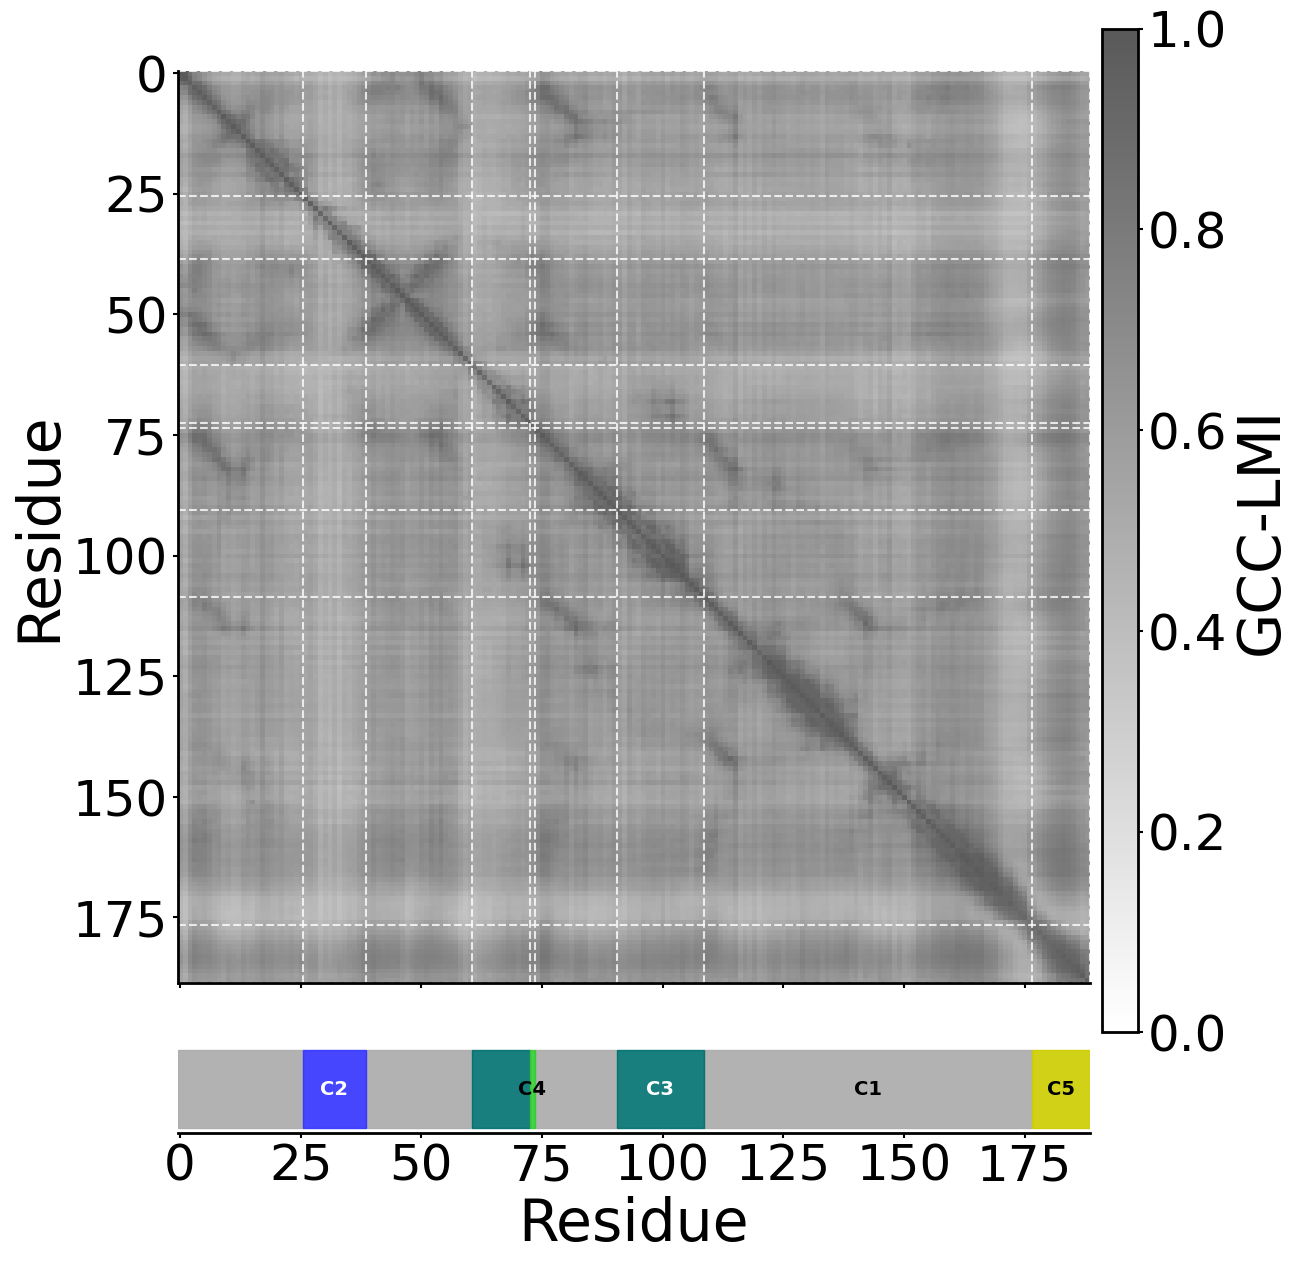

In [82]:
# ── GCC-LMI network heatmap with cluster annotation ──────────────────────
_N = gcc_network.shape[0]   # 189 — nodes are 0-based
_HMAP_FONT = 42
_SPAN_H_RATIO = 0.08

# Layout: GridSpec owns [left, right], colorbar sits in the remaining strip
_LEFT   = 0.10
_RIGHT  = 0.86   # plot area ends here
_CBAR_GAP = 0.01
_CBAR_W   = 0.03
_TOP    = 0.97
_BOT    = 0.05

fig = plt.figure(figsize=(12, 12))
gs = plt.GridSpec(
    2, 1,
    figure=fig,
    height_ratios=[1 - _SPAN_H_RATIO, _SPAN_H_RATIO],
    hspace=0.04,
    left=_LEFT, right=_RIGHT, top=_TOP, bottom=_BOT,
)

ax_heat = fig.add_subplot(gs[0])
ax_span = fig.add_subplot(gs[1], sharex=ax_heat)

# Colorbar axes positioned manually — does not touch ax_heat width
cax_heat = fig.add_axes([_RIGHT + _CBAR_GAP, _BOT + (_TOP - _BOT) * _SPAN_H_RATIO + 0.01,
                          _CBAR_W, (_TOP - _BOT) * (1 - _SPAN_H_RATIO) - 0.01])

# ── Heatmap ───────────────────────────────────────────────────────────────
im = ax_heat.imshow(
    gcc_network, cmap=_light_gray, vmin=0, vmax=1,
    aspect="equal", origin="upper",
    extent=[-0.5, _N - 0.5, _N - 0.5, -0.5],
)
ax_heat.set_ylabel("Residue", fontsize=_HMAP_FONT)
ax_heat.tick_params(axis="both", labelsize=_HMAP_FONT - 6)
ax_heat.tick_params(axis="x", labelbottom=False)
ax_heat.set_xlim(-0.5, _N - 0.5)
ax_heat.set_ylim(_N - 0.5, -0.5)
for spine in ax_heat.spines.values():
    spine.set_linewidth(2.0)

cbar = fig.colorbar(im, cax=cax_heat)
cbar.set_label("GCC-LMI", fontsize=_HMAP_FONT)
cbar.ax.tick_params(labelsize=_HMAP_FONT - 6)
cbar.outline.set_linewidth(2.0)

# ── Cluster boundary lines ────────────────────────────────────────────────
# Draw boundary lines at every contiguous span edge (handles non-contiguous clusters)
_line_kw = dict(color="white", linewidth=1.5, linestyle="--", alpha=0.8)
_all_boundaries = set()
for cluster in clusts:
    nodes = sorted(int(n) for n in cluster)
    s, p = nodes[0], nodes[0]
    for r in nodes[1:]:
        if r - p == 1:
            p = r
        else:
            _all_boundaries.add(s - 0.5)
            _all_boundaries.add(p + 0.5)
            s = p = r
    _all_boundaries.add(s - 0.5)
    _all_boundaries.add(p + 0.5)
for b in _all_boundaries:
    ax_heat.axvline(b, **_line_kw)
    ax_heat.axhline(b, **_line_kw)

# ── Cluster span row ──────────────────────────────────────────────────────
ax_span.set_xlim(-0.5, _N - 0.5)
ax_span.set_ylim(0, 1)
ax_span.set_yticks([])
for spine in ("left", "top", "right"):
    ax_span.spines[spine].set_visible(False)
ax_span.spines["bottom"].set_linewidth(2.0)

_SPAN_YMIN, _SPAN_YMAX = 0.05, 0.95

for i, cluster in enumerate(clusts):
    color = CLUSTER_COLORS[i]
    nodes = sorted(int(n) for n in cluster)
    spans_0 = []
    s, p = nodes[0], nodes[0]
    for r in nodes[1:]:
        if r - p == 1:
            p = r
        else:
            spans_0.append((s, p))
            s = p = r
    spans_0.append((s, p))
    for s, e in spans_0:
        ax_span.axvspan(s - 0.5, e + 0.5, ymin=_SPAN_YMIN, ymax=_SPAN_YMAX,
                        color=color, alpha=0.9)
    largest = max(spans_0, key=lambda se: se[1] - se[0])
    ax_span.text((largest[0] + largest[1]) / 2, 0.5, f"C{i+1}",
                 ha="center", va="center", fontsize=14,
                 color=_text_color(color), fontweight="bold", clip_on=True)

ax_span.set_xlabel("Residue", fontsize=_HMAP_FONT)
ax_span.set_xticks(range(0, _N, 25))
ax_span.tick_params(axis="x", labelsize=_HMAP_FONT - 6)

plt.savefig(SVG_DIR / "fig5a_gcc_network_heatmap.svg")
plt.show()


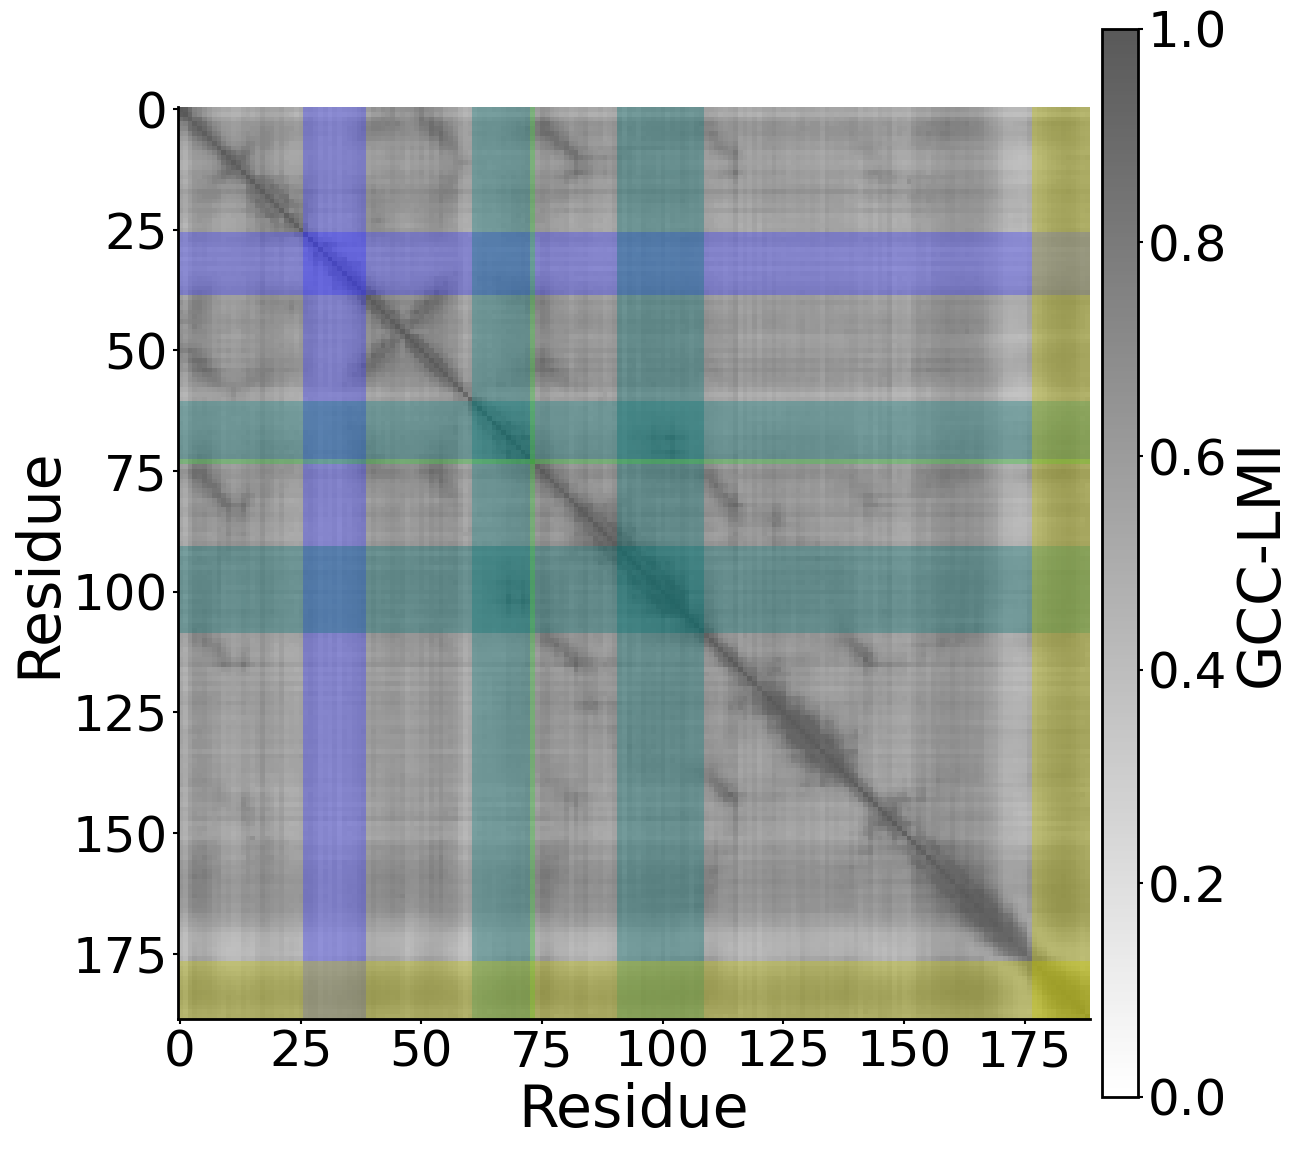

In [80]:
# ── GCC-LMI heatmap v2: cluster spans overlaid, no span row ───────────────
_N = gcc_network.shape[0]
_HMAP_FONT = 42

_LEFT     = 0.10
_RIGHT    = 0.86
_CBAR_GAP = 0.01
_CBAR_W   = 0.03
_TOP      = 0.97
_BOT      = 0.08

fig = plt.figure(figsize=(12, 12))
ax_heat = fig.add_axes([_LEFT, _BOT, _RIGHT - _LEFT, _TOP - _BOT])
cax_heat = fig.add_axes([_RIGHT + _CBAR_GAP, _BOT, _CBAR_W, _TOP - _BOT])

# ── Heatmap ───────────────────────────────────────────────────────────────
im = ax_heat.imshow(
    gcc_network, cmap=_light_gray, vmin=0, vmax=1,
    aspect="equal", origin="upper",
    extent=[-0.5, _N - 0.5, _N - 0.5, -0.5],
)
ax_heat.set_xlabel("Residue", fontsize=_HMAP_FONT)
ax_heat.set_ylabel("Residue", fontsize=_HMAP_FONT)
ax_heat.tick_params(axis="both", labelsize=_HMAP_FONT - 6)
ax_heat.set_xticks(range(0, _N, 25))
ax_heat.set_yticks(range(0, _N, 25))
ax_heat.set_xlim(-0.5, _N - 0.5)
ax_heat.set_ylim(_N - 0.5, -0.5)
for spine in ax_heat.spines.values():
    spine.set_linewidth(2.0)

cbar = fig.colorbar(im, cax=cax_heat)
cbar.set_label("GCC-LMI", fontsize=_HMAP_FONT)
cbar.ax.tick_params(labelsize=_HMAP_FONT - 6)
cbar.outline.set_linewidth(2.0)

# ── Cluster spans overlaid on heatmap (skip C1 = index 0, background) ────
for i, cluster in enumerate(clusts):
    if i == 0:
        continue
    color = CLUSTER_COLORS[i]
    nodes = sorted(int(n) for n in cluster)
    spans_0 = []
    s, p = nodes[0], nodes[0]
    for r in nodes[1:]:
        if r - p == 1:
            p = r
        else:
            spans_0.append((s, p))
            s = p = r
    spans_0.append((s, p))
    for s, e in spans_0:
        ax_heat.axvspan(s - 0.5, e + 0.5, color=color, alpha=0.35, linewidth=0)
        ax_heat.axhspan(s - 0.5, e + 0.5, color=color, alpha=0.35, linewidth=0)

plt.savefig(SVG_DIR / "fig5a_gcc_network_heatmap_v2.svg")
plt.show()


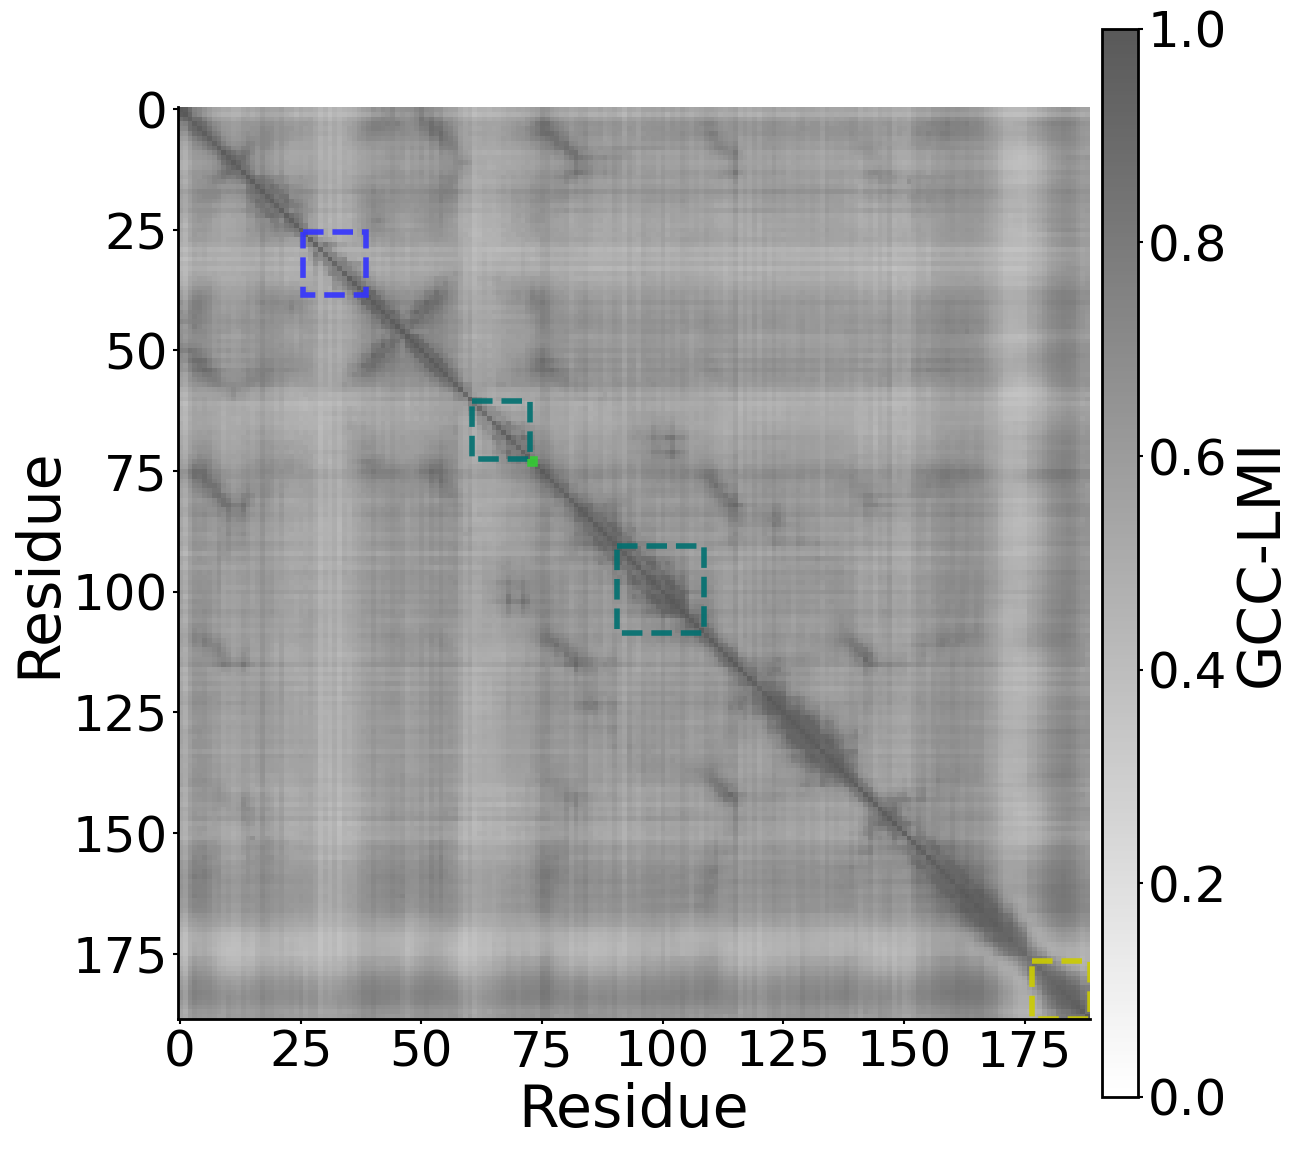

In [84]:
# ── GCC-LMI heatmap v3: colored dashed boundary lines per cluster (skip C1) ──
_N = gcc_network.shape[0]
_HMAP_FONT = 42

_LEFT     = 0.10
_RIGHT    = 0.86
_CBAR_GAP = 0.01
_CBAR_W   = 0.03
_TOP      = 0.97
_BOT      = 0.08

fig = plt.figure(figsize=(12, 12))
ax_heat = fig.add_axes([_LEFT, _BOT, _RIGHT - _LEFT, _TOP - _BOT])
cax_heat = fig.add_axes([_RIGHT + _CBAR_GAP, _BOT, _CBAR_W, _TOP - _BOT])

# ── Heatmap ───────────────────────────────────────────────────────────────
im = ax_heat.imshow(
    gcc_network, cmap=_light_gray, vmin=0, vmax=1,
    aspect="equal", origin="upper",
    extent=[-0.5, _N - 0.5, _N - 0.5, -0.5],
)
ax_heat.set_xlabel("Residue", fontsize=_HMAP_FONT)
ax_heat.set_ylabel("Residue", fontsize=_HMAP_FONT)
ax_heat.tick_params(axis="both", labelsize=_HMAP_FONT - 6)
ax_heat.set_xticks(range(0, _N, 25))
ax_heat.set_yticks(range(0, _N, 25))
ax_heat.set_xlim(-0.5, _N - 0.5)
ax_heat.set_ylim(_N - 0.5, -0.5)
for spine in ax_heat.spines.values():
    spine.set_linewidth(2.0)

cbar = fig.colorbar(im, cax=cax_heat)
cbar.set_label("GCC-LMI", fontsize=_HMAP_FONT)
cbar.ax.tick_params(labelsize=_HMAP_FONT - 6)
cbar.outline.set_linewidth(2.0)

# ── Colored dashed boxes on the diagonal per cluster (C1 skipped) ────────
# For each contiguous span of a non-background cluster, draw a dashed
# rectangle around just that diagonal block (not the full axis width).
for i, cluster in enumerate(clusts):
    if i == 0:
        continue  # C1 is background — no box
    color = CLUSTER_COLORS[i]
    _rect_kw = dict(edgecolor=color, linewidth=4.0, linestyle="--",
                    facecolor="none", alpha=0.9)
    nodes = sorted(int(n) for n in cluster)
    s, p = nodes[0], nodes[0]
    spans_0 = []
    for r in nodes[1:]:
        if r - p == 1:
            p = r
        else:
            spans_0.append((s, p))
            s = p = r
    spans_0.append((s, p))
    for s, e in spans_0:
        rect = plt.Rectangle(
            (s - 0.5, s - 0.5), (e - s + 1), (e - s + 1),
            **_rect_kw,
        )
        ax_heat.add_patch(rect)

plt.savefig(SVG_DIR / "fig5a_gcc_network_heatmap_v3.svg")
plt.show()


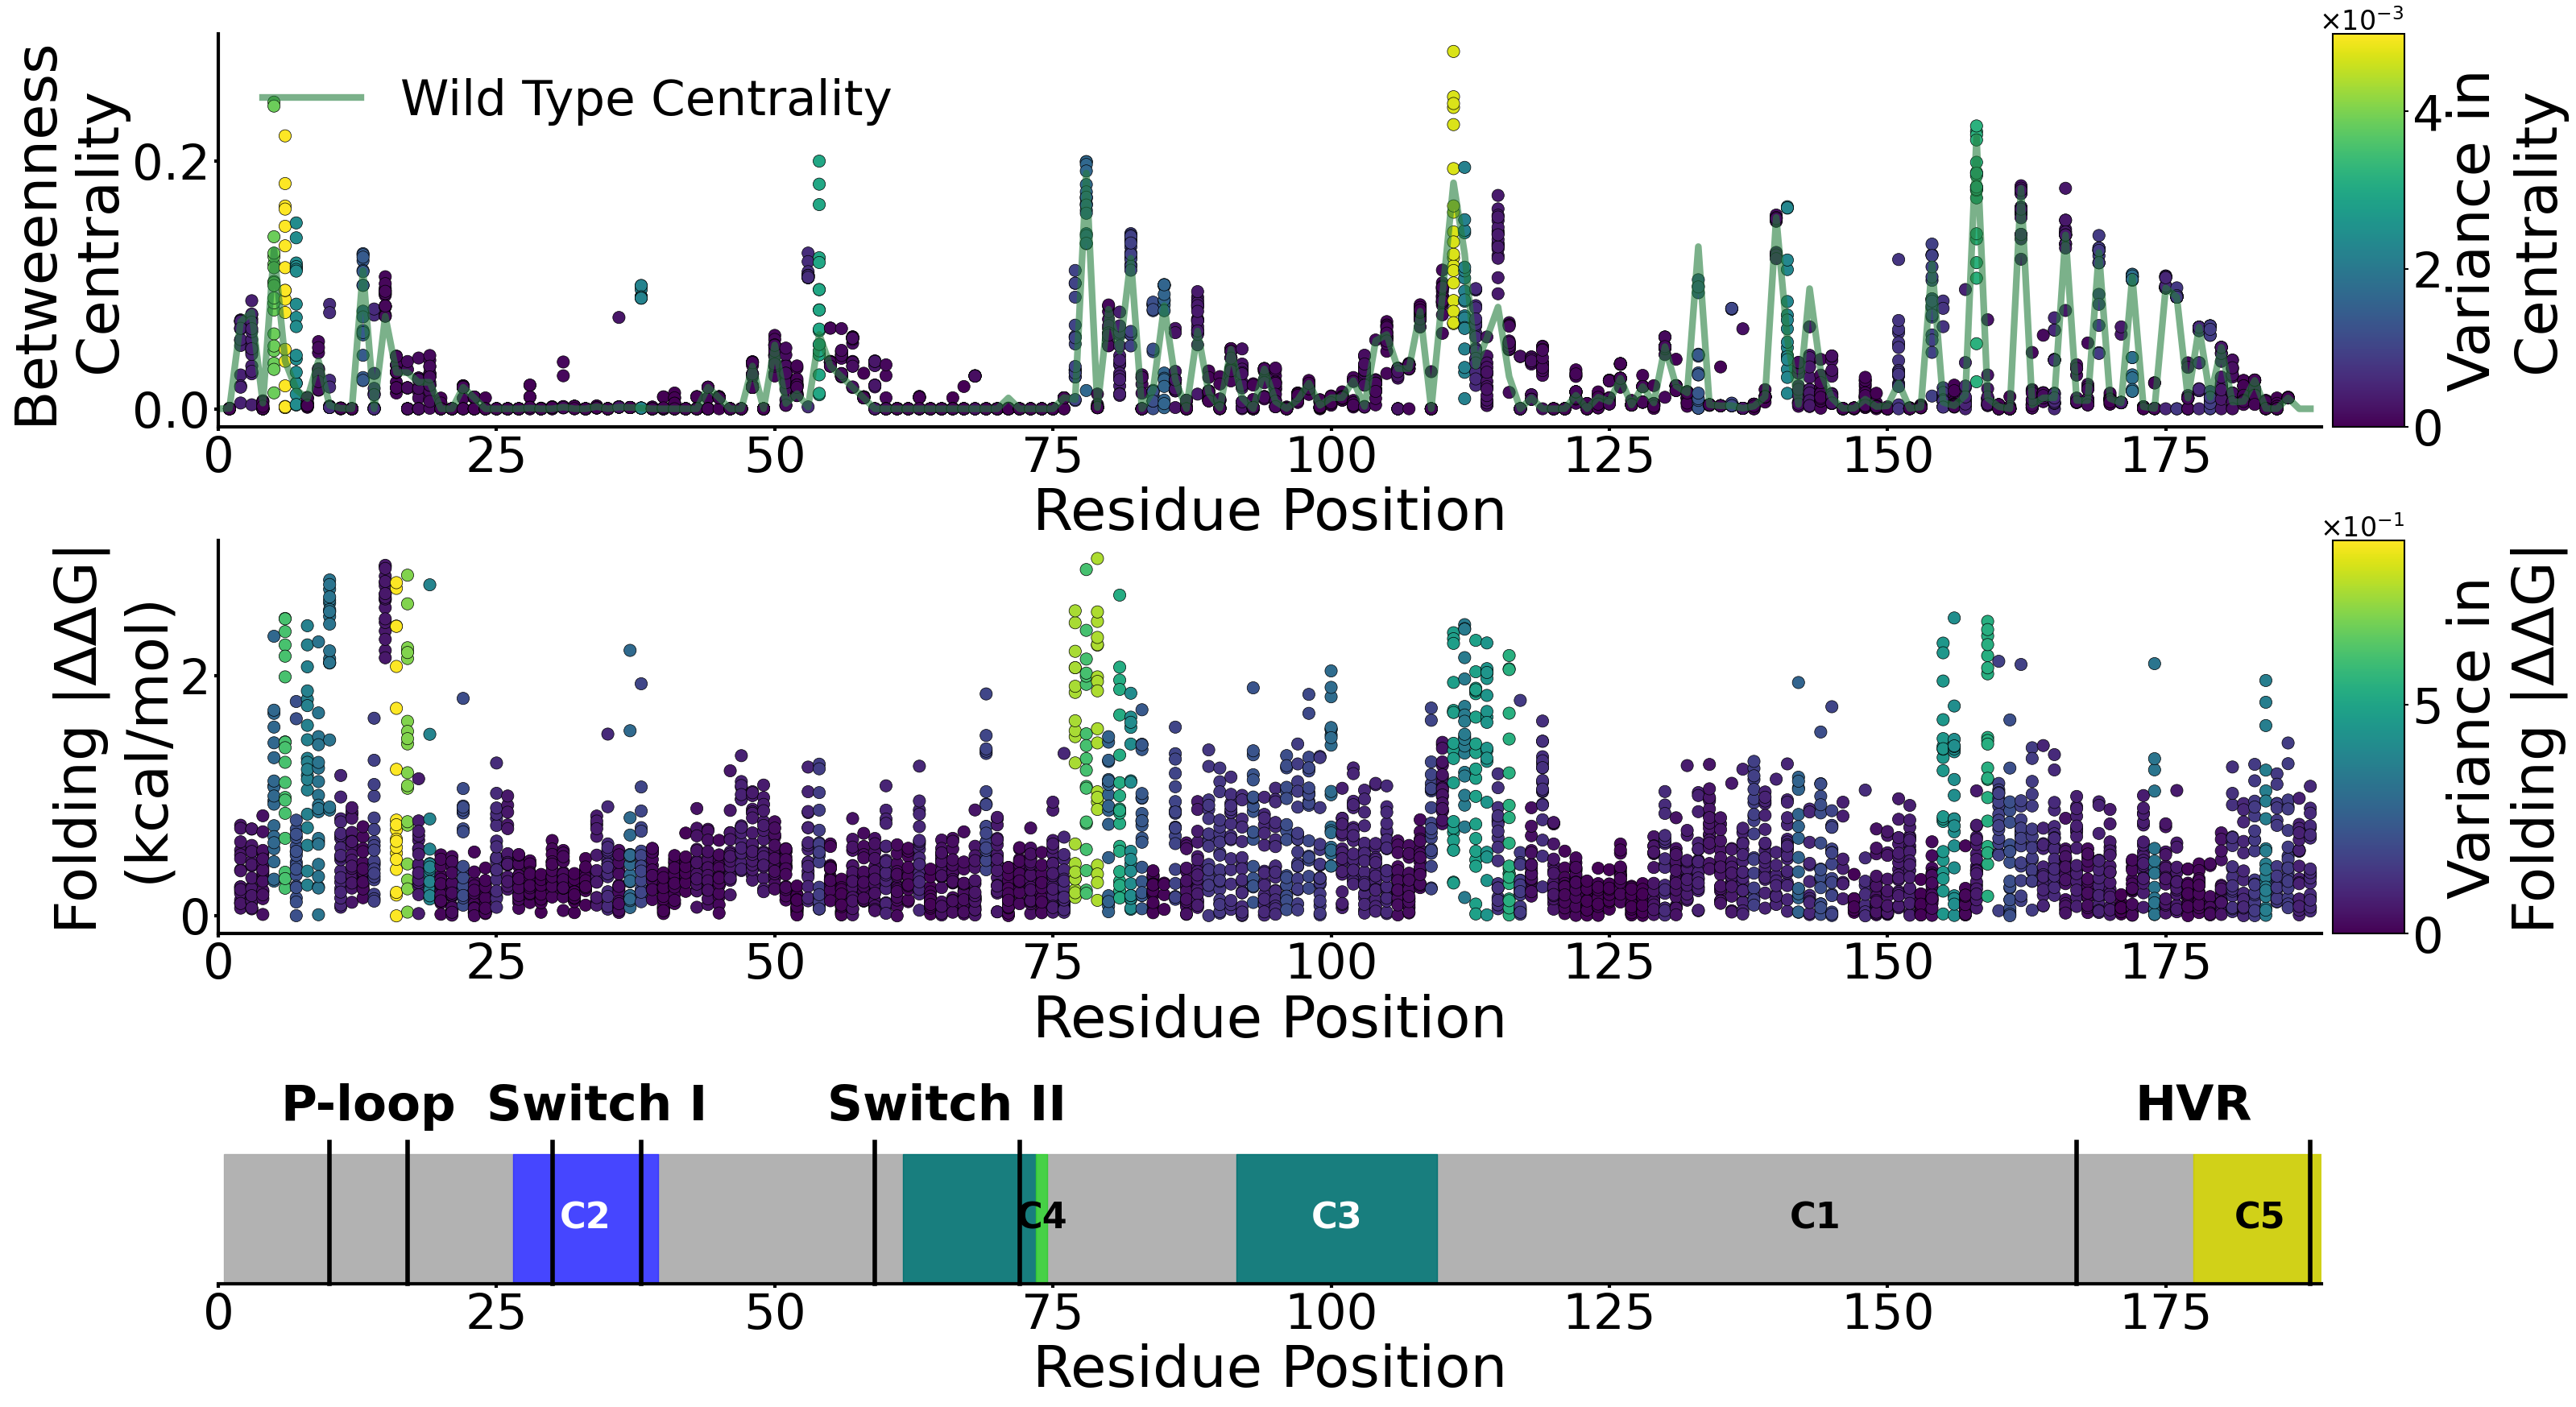

In [69]:
# ── Fig 5 combined: centrality + folding ΔΔG + annotation spans, shared x ──
# Four rows in one figure: scatter (centrality), scatter (ddg),
# annotation spans, cluster spans. All share the same x axis.

from matplotlib.gridspec import GridSpec

_SCATTER_H = 5  # height units for each scatter row
_SPAN_H = 1.5  # height units for each span row

_FIG_H_COMBINED = FIG5_H * 2.0 + 4.0
fig = plt.figure(figsize=(FIG5_W, _FIG_H_COMBINED))

gs = GridSpec(
    4,
    2,
    figure=fig,
    height_ratios=[_SCATTER_H, _SCATTER_H, _SPAN_H * 2, _SPAN_H],
    width_ratios=[PLOT_W, CBAR_GAP + CBAR_W],
    left=PLOT_LEFT,
    right=PLOT_LEFT + PLOT_W + CBAR_GAP + CBAR_W,
    top=0.97,
    bottom=0.05,
    hspace=0.40,
    wspace=0.01,
)

ax_cent = fig.add_subplot(gs[0, 0])
cax_cent = fig.add_subplot(gs[0, 1])
ax_ddg = fig.add_subplot(gs[1, 0], sharex=ax_cent)
cax_ddg = fig.add_subplot(gs[1, 1])
ax_ann = fig.add_subplot(gs[2, 0], sharex=ax_cent)
ax_clust = fig.add_subplot(gs[3, 0], sharex=ax_cent)
# Span rows have no colorbar; hide right-column cells
for _ax in (fig.add_subplot(gs[2, 1]), fig.add_subplot(gs[3, 1])):
    _ax.set_visible(False)

# ── Row 0: betweenness centrality ─────────────────────────────────────────
sns.scatterplot(
    data=res_df,
    x="pos_i",
    y="centrality",
    hue="variance_centrality",
    palette="viridis",
    hue_norm=(0, res_df["variance_centrality"].max()),
    edgecolor="black",
    linewidth=LINEWIDTH,
    alpha=1.0,
    ax=ax_cent,
    legend=False,
    s=POINT_SIZE,
)
_fill_cbar(cax_cent, "Variance in\nCentrality", "viridis", 0, res_df["variance_centrality"].max())
sns.lineplot(
    x=list(wt_centrality.keys()),
    y=list(wt_centrality.values()),
    ax=ax_cent,
    label="Wild Type Centrality",
    color=COLORS["PLANET-MD"],
    linewidth=6,
    alpha=0.6,
)
ax_cent.set_xlabel("")
ax_cent.set_ylabel("Betweenness\nCentrality", fontsize=FIG5_FONT)
ax_cent.set_xlabel("Residue Position", fontsize=FIG5_FONT)
ax_cent.tick_params(axis="both", labelsize=FIG5_FONT - 8, width=1.5, colors="black")
ax_cent.legend(loc="upper left", fontsize=FIG5_FONT - 8)
finalize(ax_cent)
ax_cent.set_xlim(0, 189)
ax_cent.margins(x=0)
for _s in ax_cent.spines.values(): _s.set_linewidth(3.0)
ax_cent.tick_params(width=3.0)

# ── Row 1: folding ΔΔG ────────────────────────────────────────────────────
sns.scatterplot(
    data=folding_ddg,
    x="Pos_real",
    y="abs_mean_kcal/mol",
    hue="variance_kcal/mol",
    palette="viridis",
    hue_norm=(0, folding_ddg["variance_kcal/mol"].max()),
    edgecolor="black",
    linewidth=LINEWIDTH,
    alpha=1.0,
    ax=ax_ddg,
    legend=False,
    s=POINT_SIZE,
)
_fill_cbar(cax_ddg, "Variance in\nFolding |\u0394\u0394G|", "viridis", 0, folding_ddg["variance_kcal/mol"].max())
ax_ddg.set_xlabel("")
ax_ddg.set_xlabel("Residue Position", fontsize=FIG5_FONT)
ax_ddg.set_ylabel("Folding |\u0394\u0394G|\n(kcal/mol)", fontsize=FIG5_FONT)
ax_ddg.tick_params(axis="both", labelsize=FIG5_FONT - 8, width=1.5, colors="black")
finalize(ax_ddg)
for _s in ax_ddg.spines.values(): _s.set_linewidth(3.0)
ax_ddg.tick_params(width=3.0)

# ── Rows 2 & 3: cluster spans + annotation tick-lines ────────────────────
# ax_ann holds the combined single row; ax_clust is hidden
_SPAN_YMIN, _SPAN_YMAX = 0.0, 0.55
_TICK_LO,   _TICK_HI   = 0.45, 0.60
_LABEL_Y                = 0.75
_SPAN_FONT  = 32

for ax in (ax_ann, ax_clust):
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    for spine in ("left", "top", "right"):
        ax.spines[spine].set_visible(False)

# Cluster spans
for i, cluster in enumerate(clusts):
    color = CLUSTER_COLORS[i]
    spans = _get_spans(cluster)
    for s, e in spans:
        ax_ann.axvspan(s - 0.5, e + 0.5, ymin=_SPAN_YMIN, ymax=_SPAN_YMAX,
                    color=color, alpha=0.9)
    largest = max(spans, key=lambda se: se[1] - se[0])
    ax_ann.text((largest[0] + largest[1]) / 2, _SPAN_YMAX / 2, f"C{i+1}",
                ha="center", va="center", fontsize=_SPAN_FONT,
                color=_text_color(color), fontweight="bold", clip_on=True)

# Region annotation tick lines + labels above spans
_tick_kw = dict(color="black", linewidth=4.0, clip_on=False)
for name, (start, end) in REGION_ANNOTATIONS:
    ax_ann.axvline(start, ymin=0, ymax=_TICK_HI, **_tick_kw)
    ax_ann.axvline(end,   ymin=0, ymax=_TICK_HI, **_tick_kw)
    ax_ann.text((start + end) / 2, _LABEL_Y, name,
                ha="center", va="center", fontsize=FIG5_FONT - 8,
                color="black", fontweight="bold", clip_on=False)

ax_ann.tick_params(axis="x", labelbottom=True, labelsize=FIG5_FONT - 8, colors="black", width=3.0)
ax_ann.spines["bottom"].set_visible(True)
ax_ann.spines["bottom"].set_linewidth(3.0)
ax_ann.set_xlabel("Residue Position", fontsize=FIG5_FONT)

ax_clust.set_visible(False)
plt.savefig(SVG_DIR / "fig5_kras_combined.svg")
plt.show()


## Fig 6a — Extrapolated runtimes across databases

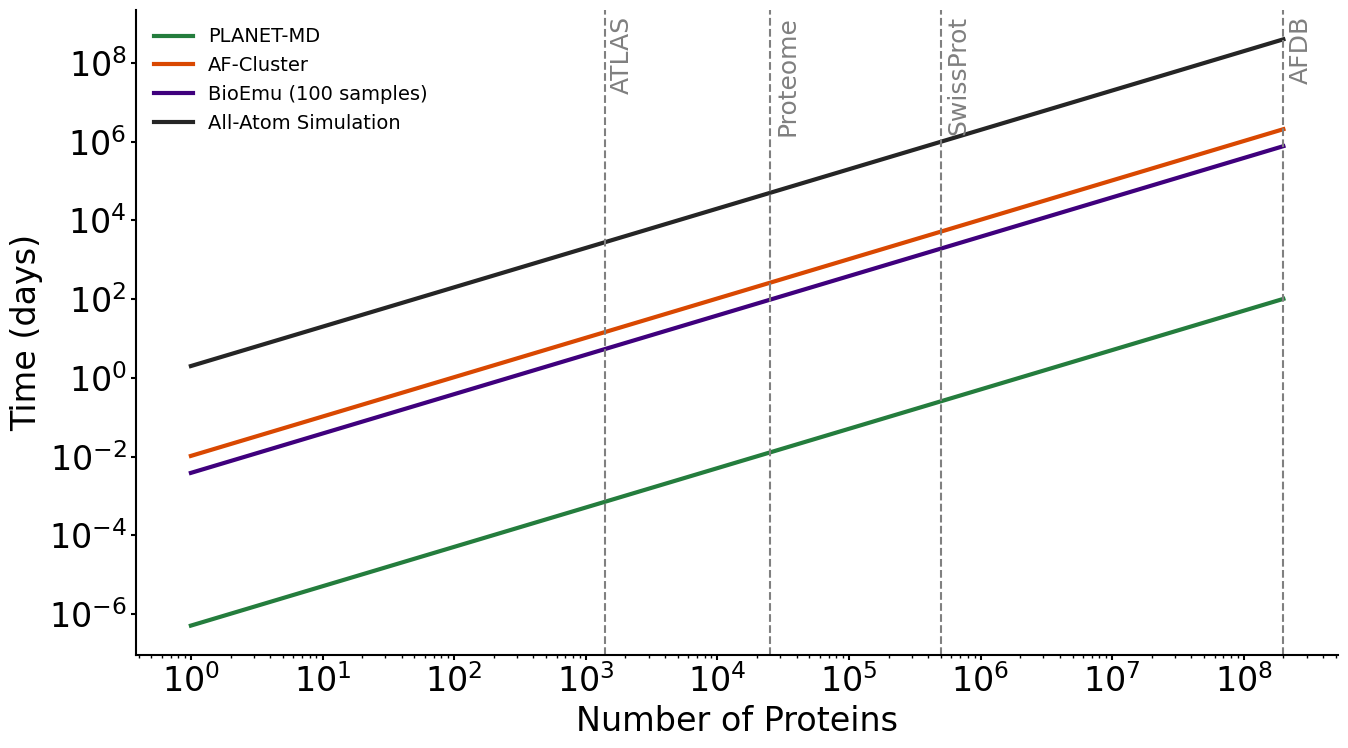

In [23]:
with open(ATLAS_PRECOMPUTED / "runtime_times.json") as f:
    rt = json.load(f)

AF_CLUSTER_TIME = 15 * minutes
SIM_TIME = 2 * days

TIME_PER = {
    "PLANET-MD": np.mean(rt["PLANET-MD"]),
    # "PLANET-MD mini": np.mean(rt["PLANET-MD mini"]),
    # "Dyna-1": np.mean(rt["Dyna-1"]),
    "AF-Cluster": AF_CLUSTER_TIME,
    # "BioEmu (10 samples)": np.mean(rt["BioEmu (10 samples)"]),
    "BioEmu (100 samples)": np.mean(rt["BioEmu (100 samples)"]),
    "All-Atom Simulation": SIM_TIME,
}

x_range = np.logspace(0, np.log10(AFDB_SIZE + 1))

fig, ax = plt.subplots(figsize=(14,8))
for name, time in TIME_PER.items():
    ax.plot(x_range, x_range * time / days, label=name, c=COLORS[name], linewidth=3)

ax.set_xlabel("Number of Proteins")
ax.set_ylabel("Time (days)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(fontsize=14)

# Vertical reference lines with labels pinned to top of axes
ymin, ymax = ax.get_ylim()
for label, point in zip(
    ["ATLAS", "Proteome", "SwissProt", "AFDB"],
    [ATLAS_SIZE, PROTEOME_SIZE, SWISSPROT_SIZE, AFDB_SIZE],
):
    ax.axvline(point, color="grey", linestyle="--")
    ax.text(
        point * 1.1, ymax * 0.7,
        label, rotation=90, va="top", fontsize=18, color="grey",
    )

finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig6a_runtime_extrapolation.svg")
plt.show()

## Fig 6b — Disordered vs. other regions: predicted RMSF

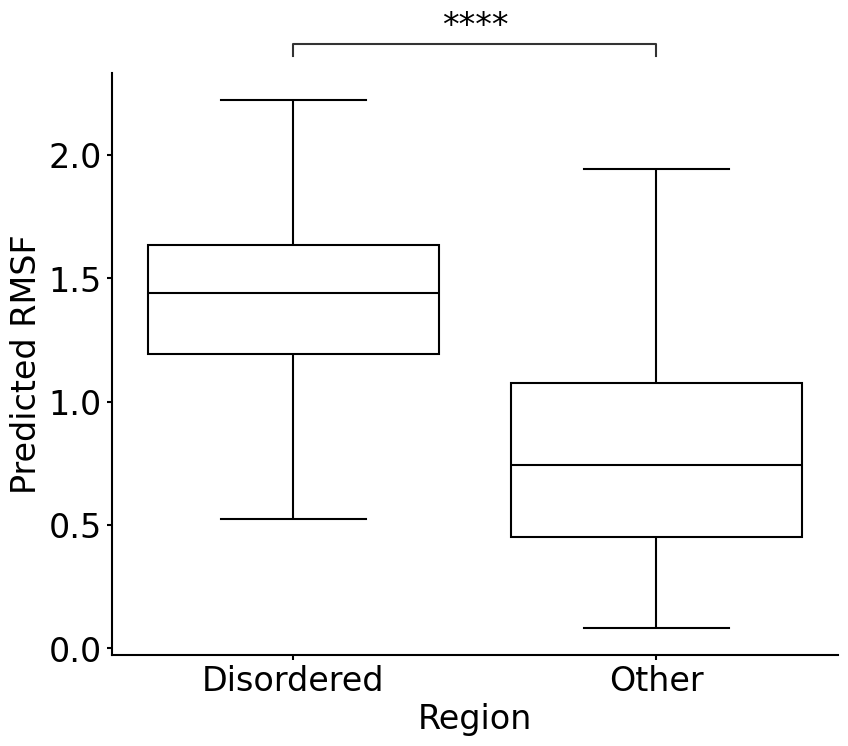

RMSF  Disordered vs Other: U=106308571, p=0.000e+00, n=11093 vs 10998


In [108]:
disordered_df = pd.read_csv(PROTEOME_PRECOMPUTED / "disordered_rmsf.csv")

fig, ax = plt.subplots(figsize=(9,8))
sns.boxplot(data=disordered_df, x="variable", y="value", ax=ax,
            color="white", linecolor="black", linewidth=1.5, fliersize=0)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Disordered", "Other"])
ax.set_xlabel("Region")
ax.set_yticks([0, 0.5, 1, 1.5, 2])
ax.set_ylabel("Predicted RMSF")

annotator = Annotator(ax, [("type_rmsf", "other_rmsf")],
                      data=disordered_df, x="variable", y="value")
annotator.configure(test="Mann-Whitney", text_format="star", loc="outside", verbose=0)
annotator.apply_and_annotate()

finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig6b_disordered_rmsf.svg")
plt.show()

# ── Significance stats for caption ──────────────────────────────────────
from scipy.stats import mannwhitneyu as _mwu
_x = disordered_df.loc[disordered_df["variable"] == "type_rmsf", "value"].dropna().values
_y = disordered_df.loc[disordered_df["variable"] == "other_rmsf", "value"].dropna().values
_u, _p = _mwu(_x, _y, alternative="two-sided")
print(f"RMSF  Disordered vs Other: U={_u:.0f}, p={_p:.3e}, n={len(_x)} vs {len(_y)}")


## Fig 6b (violin) — Disordered vs. other regions: predicted RMSF

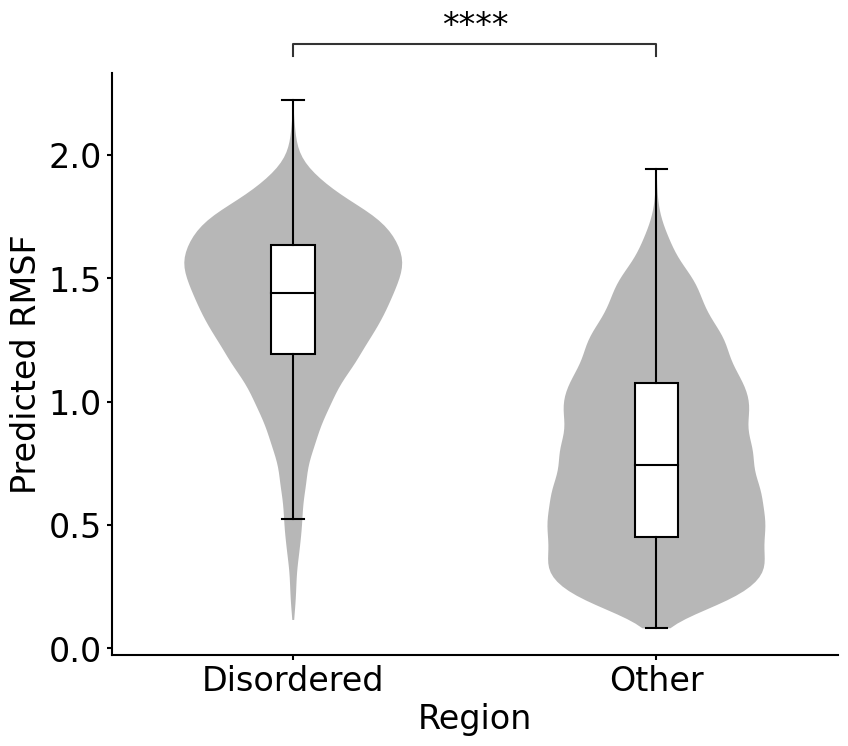

RMSF (violin)  Disordered vs Other: U=106308571, p=0.000e+00, n=11093 vs 10998


In [107]:
fig, ax = plt.subplots(figsize=(9, 8))

groups = [("type_rmsf", "Disordered"), ("other_rmsf", "Other")]
for i, (var, lbl) in enumerate(groups):
    vals = disordered_df.loc[disordered_df["variable"] == var, "value"].dropna().values
    if vals.std() > 1e-9:
        vp = ax.violinplot(vals, positions=[i], widths=0.6,
                           showmeans=False, showmedians=False, showextrema=False)
        for body in vp["bodies"]:
            body.set_facecolor(seq_color)
            body.set_alpha(0.6)
            body.set_edgecolor("none")
    q1, med, q3 = np.percentile(vals, [25, 50, 75])
    iqr = q3 - q1
    lo = max(vals.min(), q1 - 1.5 * iqr)
    hi = min(vals.max(), q3 + 1.5 * iqr)
    bw = 0.12
    rect = mpatches.FancyBboxPatch(
        (i - bw / 2, q1), bw, iqr,
        boxstyle="square,pad=0",
        linewidth=1.5, edgecolor="black", facecolor="white", zorder=3,
    )
    ax.add_patch(rect)
    ax.plot([i - bw / 2, i + bw / 2], [med, med], color="black", linewidth=1.5, zorder=4)
    ax.plot([i, i], [q1, lo], color="black", linewidth=1.5, zorder=3)
    ax.plot([i, i], [q3, hi], color="black", linewidth=1.5, zorder=3)
    cap_w = bw * 0.5
    for cap_y in [lo, hi]:
        ax.plot([i - cap_w / 2, i + cap_w / 2], [cap_y, cap_y],
                color="black", linewidth=1.5, zorder=3)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Disordered", "Other"])
ax.set_xlabel("Region")
ax.set_ylabel("Predicted RMSF")
ax.set_xlim(-0.5, 1.5)

annot_df = disordered_df.copy()
annot_df["group"] = annot_df["variable"].map({"type_rmsf": "Disordered", "other_rmsf": "Other"})
annotator = Annotator(ax, [("Disordered", "Other")],
    data=annot_df, x="group", y="value", order=["Disordered", "Other"])
annotator.configure(test="Mann-Whitney", text_format="star", loc="outside", verbose=0)
annotator.apply_and_annotate()

finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig6b_disordered_rmsf_violin.svg")
plt.show()

# ── Significance stats for caption ──────────────────────────────────────
from scipy.stats import mannwhitneyu as _mwu
_x = disordered_df.loc[disordered_df["variable"] == "type_rmsf", "value"].dropna().values
_y = disordered_df.loc[disordered_df["variable"] == "other_rmsf", "value"].dropna().values
_u, _p = _mwu(_x, _y, alternative="two-sided")
print(f"RMSF (violin)  Disordered vs Other: U={_u:.0f}, p={_p:.3e}, n={len(_x)} vs {len(_y)}")


## Fig 6c — Subcellular location distribution (pie chart)

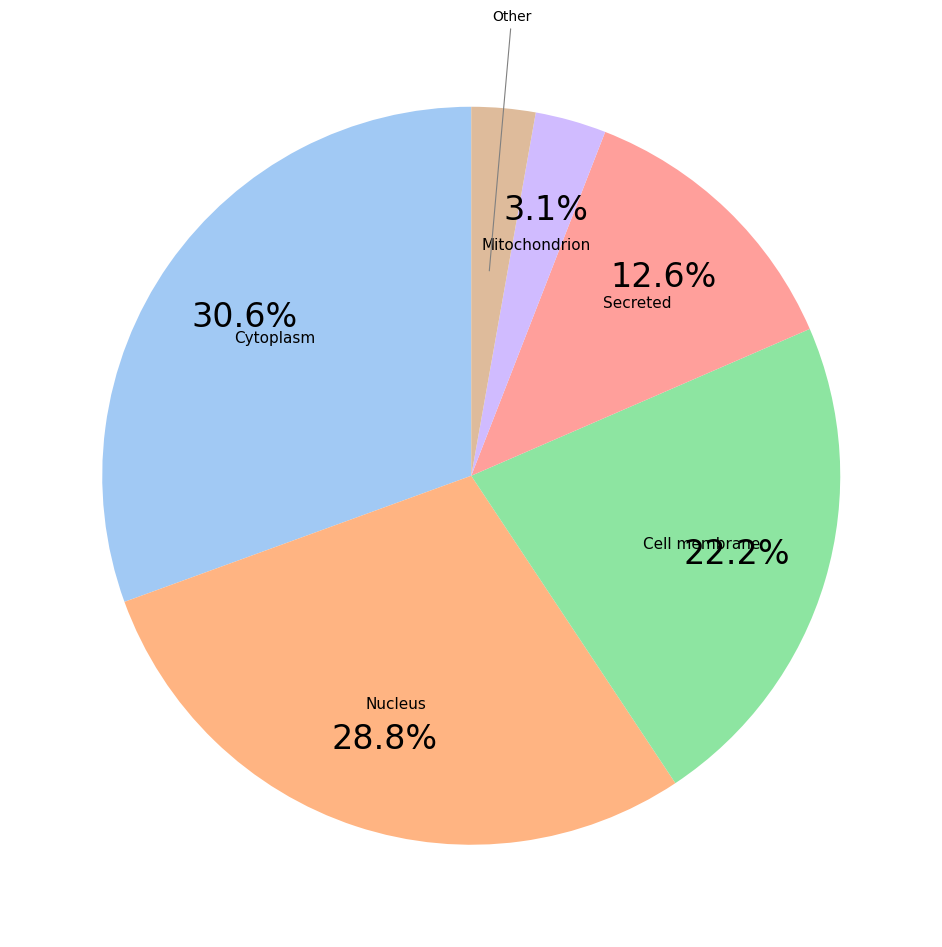

In [26]:
subcell_counts = pd.read_csv(PROTEOME_PRECOMPUTED / "subcellular_location_counts.csv")

fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(
    subcell_counts["count"],
    labels=None,
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 3 else "",
    startangle=90,
    colors=sns.color_palette("pastel"),
    pctdistance=0.75,
)

# For small slices, draw label + line outside the wedge
for i, (wedge, label) in enumerate(zip(wedges, subcell_counts["subcellular_location"])):
    angle = (wedge.theta1 + wedge.theta2) / 2
    pct = subcell_counts["count"].iloc[i] / subcell_counts["count"].sum() * 100
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))
    if pct < 3:
        x_out, y_out = 1.25 * x, 1.25 * y
        ax.annotate(
            label,
            xy=(0.55 * x, 0.55 * y),
            xytext=(x_out, y_out),
            ha="center" if abs(x) < 0.5 else ("left" if x > 0 else "right"),
            va="center",
            fontsize=10,
            arrowprops=dict(arrowstyle="-", color="gray", lw=0.8),
        )
    else:
        ax.text(
            0.65 * x, 0.65 * y, label,
            ha="center", va="center", fontsize=11,
        )

plt.tight_layout()
plt.savefig(SVG_DIR / "fig6c_subcellular_pie.svg")
plt.show()

## Fig 6d — Predicted RMSF by subcellular location

/tmp/ipykernel_978849/148911109.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped, rotation=0, ha="center", fontsize=max(FONT_SIZE - 8, 10))


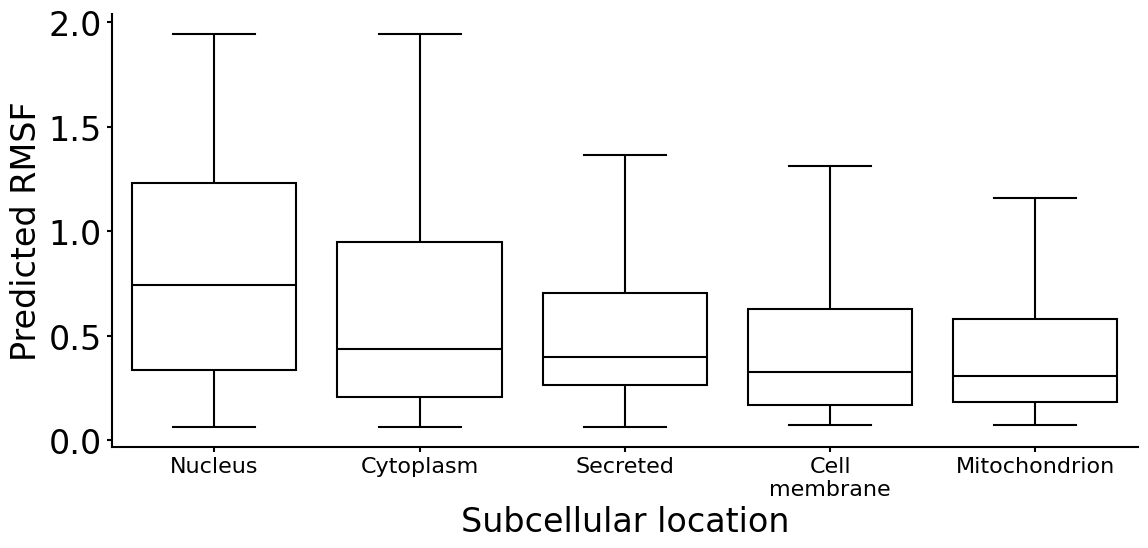

Kruskal-Wallis: H=1344.73, p=6.680e-290, k=5 groups

Pairwise Mann-Whitney (Bonferroni n=10):
  Nucleus vs Cytoplasm: U=18872124, p=3.606e-102, p_adj=3.606e-101, n=5405 vs 5651
  Nucleus vs Secreted: U=7334294, p=5.905e-91, p_adj=5.905e-90, n=5405 vs 2086
  Nucleus vs Cell membrane: U=14226098, p=3.284e-254, p_adj=3.284e-253, n=5405 vs 3709
  Nucleus vs Mitochondrion: U=2456646, p=9.268e-70, p_adj=9.268e-69, n=5405 vs 637
  Cytoplasm vs Secreted: U=6013536, p=1.703e-01, p_adj=1.000e+00, n=5651 vs 2086
  Cytoplasm vs Cell membrane: U=12250281, p=1.339e-43, p_adj=1.339e-42, n=5651 vs 3709
  Cytoplasm vs Mitochondrion: U=2107200, p=1.480e-12, p_adj=1.480e-11, n=5651 vs 637
  Secreted vs Cell membrane: U=4537836, p=6.684e-28, p_adj=6.684e-27, n=2086 vs 3709
  Secreted vs Mitochondrion: U=792358, p=1.731e-13, p_adj=1.731e-12, n=2086 vs 637
  Cell membrane vs Mitochondrion: U=1183468, p=9.414e-01, p_adj=1.000e+00, n=3709 vs 637


In [112]:
subcell_rmsf = pd.read_csv(PROTEOME_PRECOMPUTED / "subcellular_location_rmsf.csv")

order = (
    subcell_rmsf.groupby("variable")["value"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=subcell_rmsf, x="variable", y="value", order=order, ax=ax,
            color="white", linecolor="black", linewidth=1.5, fliersize=0)
ax.set_xlabel("Subcellular location")
ax.set_ylabel("Predicted RMSF")

labels = [t.get_text() for t in ax.get_xticklabels()]
wrapped = [l.replace(" ", "\n") if len(l) > 12 else l for l in labels]
ax.set_xticklabels(wrapped, rotation=0, ha="center", fontsize=max(FONT_SIZE - 8, 10))

finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig6d_subcellular_rmsf.svg")
plt.show()
# ── Statistical tests for caption ────────────────────────────────────────
from scipy.stats import kruskal, mannwhitneyu as _mwu
from itertools import combinations as _combs

_groups = {loc: subcell_rmsf.loc[subcell_rmsf["variable"] == loc, "value"].dropna().values
           for loc in order}

# Omnibus: Kruskal-Wallis across all groups
_kw_stat, _kw_p = kruskal(*_groups.values())
print(f"Kruskal-Wallis: H={_kw_stat:.2f}, p={_kw_p:.3e}, k={len(_groups)} groups")

# Pairwise Mann-Whitney with Bonferroni correction
_pairs = list(_combs(order, 2))
_n_pairs = len(_pairs)
print(f"\nPairwise Mann-Whitney (Bonferroni n={_n_pairs}):")
for _a, _b in _pairs:
    _u, _p = _mwu(_groups[_a], _groups[_b], alternative="two-sided")
    _p_adj = min(_p * _n_pairs, 1.0)
    print(f"  {_a} vs {_b}: U={_u:.0f}, p={_p:.3e}, p_adj={_p_adj:.3e}, "
          f"n={len(_groups[_a])} vs {len(_groups[_b])}")


## Fig 6d (violin) — Predicted RMSF by subcellular location

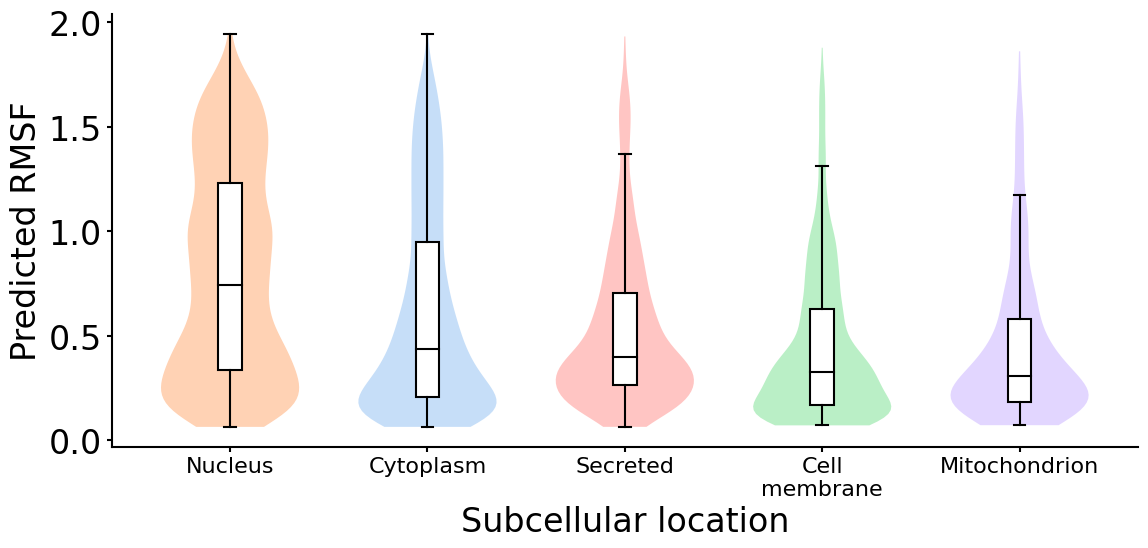

In [111]:
# Build color map from pie chart palette (same order as subcell_counts)
pie_palette = sns.color_palette("pastel", n_colors=len(subcell_counts))
pie_color_map = dict(zip(subcell_counts["subcellular_location"], pie_palette))

fig, ax = plt.subplots(figsize=(12, 6))

for i, loc in enumerate(order):
    vals = subcell_rmsf.loc[subcell_rmsf["variable"] == loc, "value"].dropna().values
    color = pie_color_map[loc]

    # violin
    if vals.std() > 1e-9:
        vp = ax.violinplot(vals, positions=[i], widths=0.7,
                           showmeans=False, showmedians=False, showextrema=False)
        for body in vp["bodies"]:
            body.set_facecolor(color)
            body.set_alpha(0.6)
            body.set_edgecolor("none")

    # box
    q1, med, q3 = np.percentile(vals, [25, 50, 75])
    iqr = q3 - q1
    lo = max(vals.min(), q1 - 1.5 * iqr)
    hi = min(vals.max(), q3 + 1.5 * iqr)
    bw = 0.12
    rect = mpatches.FancyBboxPatch(
        (i - bw / 2, q1), bw, iqr,
        boxstyle="square,pad=0",
        linewidth=1.5, edgecolor="black", facecolor="white", zorder=3,
    )
    ax.add_patch(rect)
    ax.plot([i - bw / 2, i + bw / 2], [med, med], color="black", linewidth=1.5, zorder=4)
    ax.plot([i, i], [q1, lo], color="black", linewidth=1.5, zorder=3)
    ax.plot([i, i], [q3, hi], color="black", linewidth=1.5, zorder=3)
    cap_w = bw * 0.5
    for cap_y in [lo, hi]:
        ax.plot([i - cap_w / 2, i + cap_w / 2], [cap_y, cap_y],
                color="black", linewidth=1.5, zorder=3)

ax.set_xticks(range(len(order)))
wrapped = [l.replace(" ", "\n") if len(l) > 12 else l for l in order]
ax.set_xticklabels(wrapped, rotation=0, ha="center", fontsize=max(FONT_SIZE - 8, 10))
ax.set_xlabel("Subcellular location")
ax.set_ylabel("Predicted RMSF")
ax.set_xlim(-0.6, len(order) - 0.4)
finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig6d_subcellular_rmsf_violin.svg")
plt.show()

## Fig 7 — Structure ablation: Struct+Seq vs. Seq-Only scatter plots

## Fig 7b — Structure ablation: summary bar plots

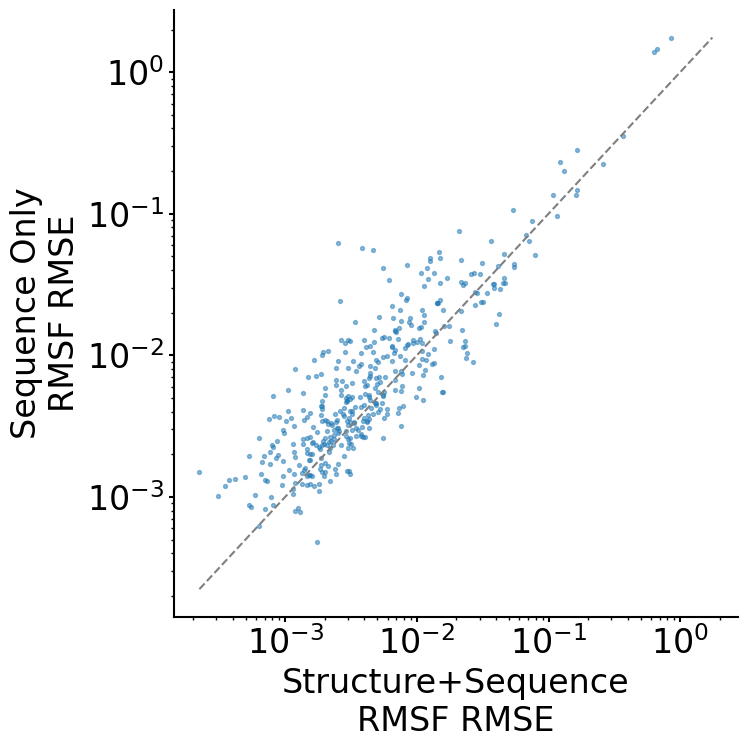

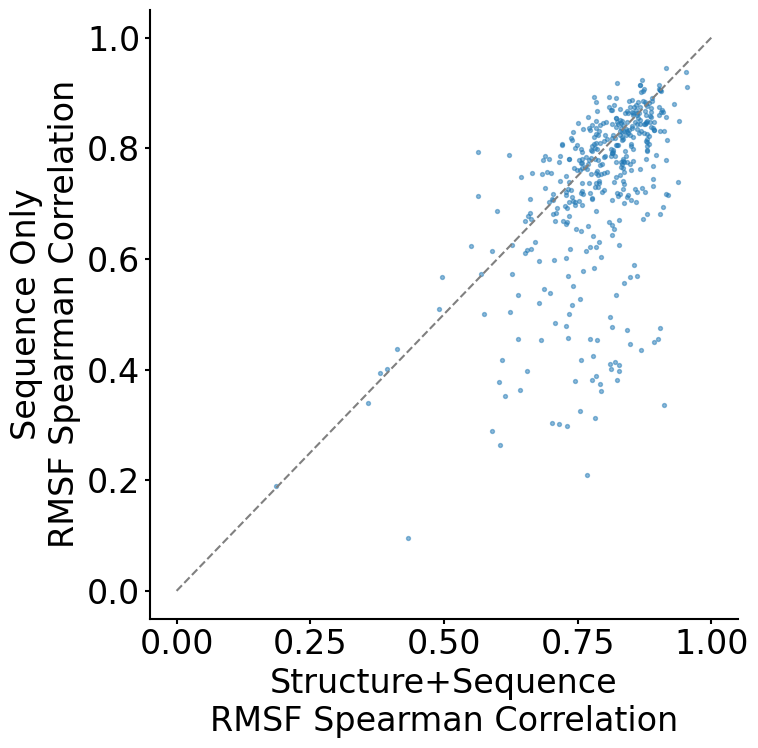

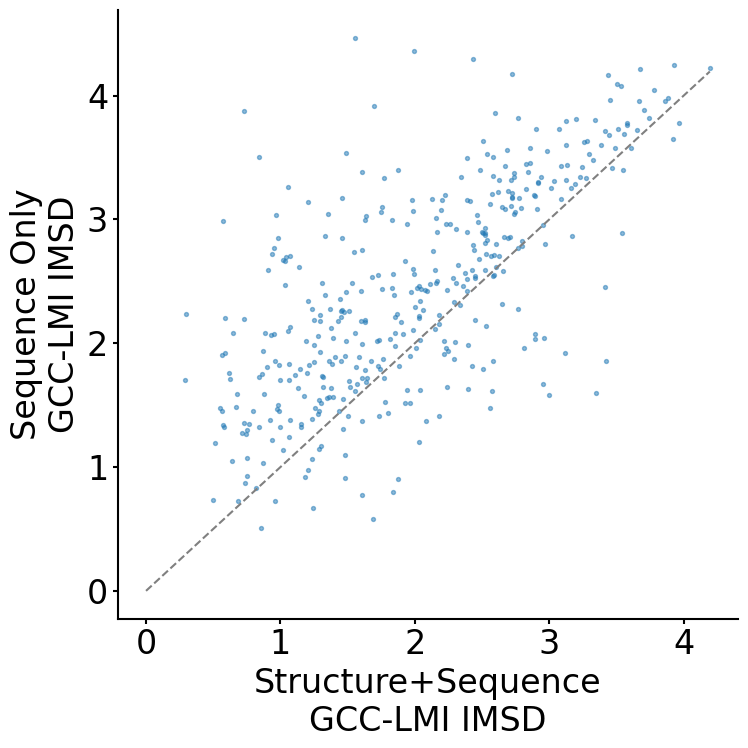

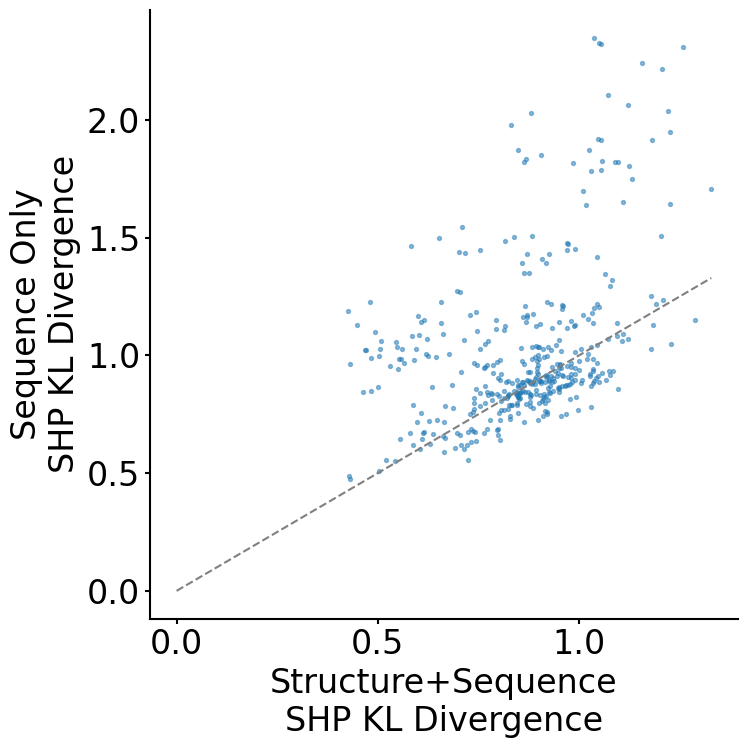

In [29]:
def load_test_metrics(results_dir, eval_key):
    csv_path = results_dir / f"{eval_key}_test_metrics.csv"
    pkl_path = results_dir / f"{eval_key}_test_metrics.pkl"
    if csv_path.exists():
        return pd.read_csv(csv_path, index_col=0)
    if pkl_path.exists():
        with open(pkl_path, "rb") as f:
            return pk.load(f)
    raise FileNotFoundError(f"No test metrics found for {eval_key} in {results_dir}")


STRUCT_MODEL_KEY = "struct_encoded"
SEQ_MODEL_KEY = "seq_only"

struct_results = load_test_metrics(
    config.EVALUATION_DATA_DIR / "evaluations" / STRUCT_MODEL_KEY, STRUCT_MODEL_KEY
)
seq_results = load_test_metrics(
    config.EVALUATION_DATA_DIR / "evaluations" / SEQ_MODEL_KEY, SEQ_MODEL_KEY
)

seq_results.columns = [f"seq_{c}" for c in seq_results.columns]
all_results = pd.merge(struct_results, seq_results, left_index=True, right_index=True)

SIZE = 8
ALPHA = 0.5

# RMSF RMSE
fig, ax = plt.subplots(figsize=FIG_SQUARE)
ax.scatter(all_results["rmsf_mse"], all_results["seq_rmsf_mse"], s=SIZE, alpha=ALPHA)
ax.set_xlabel("Structure+Sequence\nRMSF RMSE")
ax.set_ylabel("Sequence Only\nRMSF RMSE")
ax.set_xscale("log")
ax.set_yscale("log")
lim = (all_results[["rmsf_mse", "seq_rmsf_mse"]].stack().min(),
       all_results[["rmsf_mse", "seq_rmsf_mse"]].stack().max())
ax.plot(lim, lim, color="gray", linestyle="--")
finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig7_struct_ablation_rmsf_rmse_scatter.svg")
plt.show()

# RMSF Spearman
fig, ax = plt.subplots(figsize=FIG_SQUARE)
ax.scatter(all_results["rmsf_spearman_r"], all_results["seq_rmsf_spearman_r"], s=SIZE, alpha=ALPHA)
ax.set_xlabel("Structure+Sequence\nRMSF Spearman Correlation")
ax.set_ylabel("Sequence Only\nRMSF Spearman Correlation")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--")
finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig7_struct_ablation_rmsf_scatter.svg")
plt.show()

# GCC-LMI IMSD
fig, ax = plt.subplots(figsize=FIG_SQUARE)
ax.scatter(all_results["gcc_im_dist"], all_results["seq_gcc_im_dist"], s=SIZE, alpha=ALPHA)
ax.set_xlabel("Structure+Sequence\nGCC-LMI IMSD")
ax.set_ylabel("Sequence Only\nGCC-LMI IMSD")
xmax = all_results["gcc_im_dist"].max()
ax.plot([0, xmax], [0, xmax], color="gray", linestyle="--")
finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig7_struct_ablation_gcc_scatter.svg")
plt.show()

# SHP KL Divergence
fig, ax = plt.subplots(figsize=FIG_SQUARE)
ax.scatter(all_results["shp_kl_div"], all_results["seq_shp_kl_div"], s=SIZE, alpha=ALPHA)
ax.set_xlabel("Structure+Sequence\nSHP KL Divergence")
ax.set_ylabel("Sequence Only\nSHP KL Divergence")
xmax = all_results["shp_kl_div"].max()
ax.plot([0, xmax], [0, xmax], color="gray", linestyle="--")
finalize(ax)
plt.tight_layout()
plt.savefig(SVG_DIR / "fig7_struct_ablation_shp_scatter.svg")
plt.show()

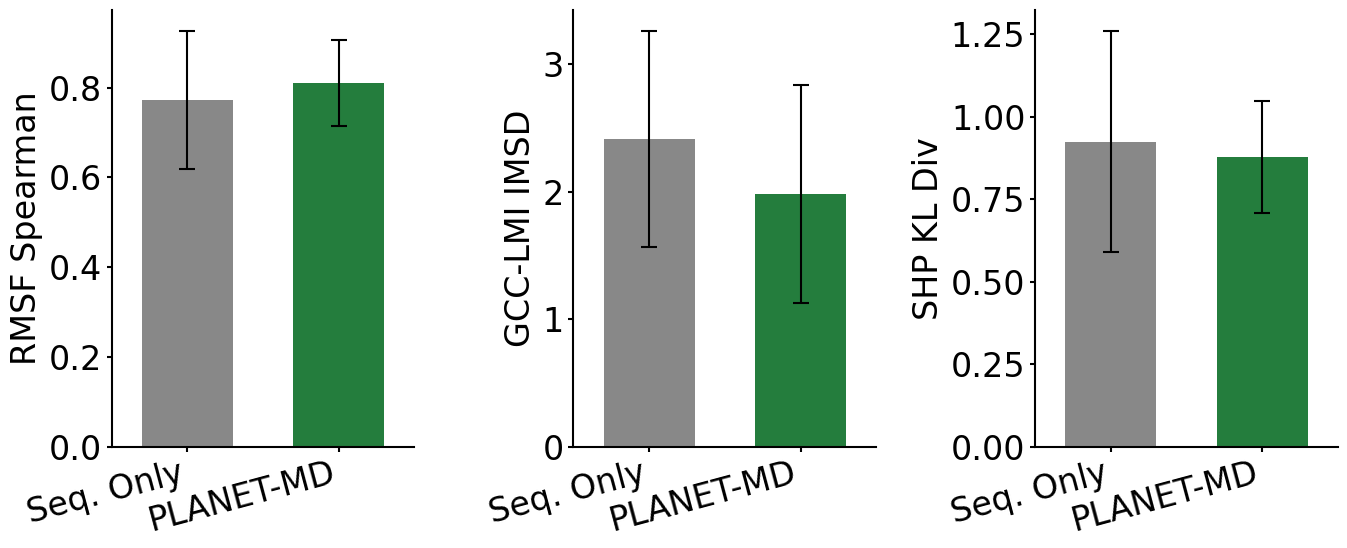

In [30]:
RMSF_METRIC = "spearman"  # "spearman" or "rmse"

if RMSF_METRIC == "spearman":
    rmsf_struct_col, rmsf_seq_col, rmsf_label = "rmsf_spearman_r", "seq_rmsf_spearman_r", "RMSF Spearman"
else:
    rmsf_struct_col, rmsf_seq_col, rmsf_label = "rmsf_mse", "seq_rmsf_mse", "RMSF RMSE"

metrics_cfg = [
    (rmsf_struct_col, rmsf_seq_col,    rmsf_label),
    ("gcc_im_dist",   "seq_gcc_im_dist", "GCC-LMI IMSD"),
    ("shp_kl_div",    "seq_shp_kl_div",  "SHP KL Div"),
]

BAR_W = 0.6

fig, axes = plt.subplots(1, 3, figsize=(14, 6))

for ax, (struct_col, seq_col, label) in zip(axes, metrics_cfg):
    struct_vals = all_results[struct_col]
    seq_vals    = all_results[seq_col]

    struct_med = struct_vals.median()
    seq_med    = seq_vals.median()
    struct_err = struct_vals.std()
    seq_err    = seq_vals.std()

    ax.bar(
        [0, 1], [seq_med, struct_med],
        width=BAR_W,
        color=[seq_color, struct_color],
        yerr=[seq_err, struct_err],
        error_kw=dict(ecolor="black", capsize=6, capthick=1.5, elinewidth=1.5),
    )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Seq. Only", "PLANET-MD"], rotation=15, ha="right")
    ax.set_ylabel(label)
    ax.set_xlim(-0.5, 1.5)
    finalize(ax)

plt.tight_layout()
plt.savefig(SVG_DIR / "fig7b_struct_ablation_barplot.svg")
plt.show()

## Fig 7c — Structure ablation: violin + box plots

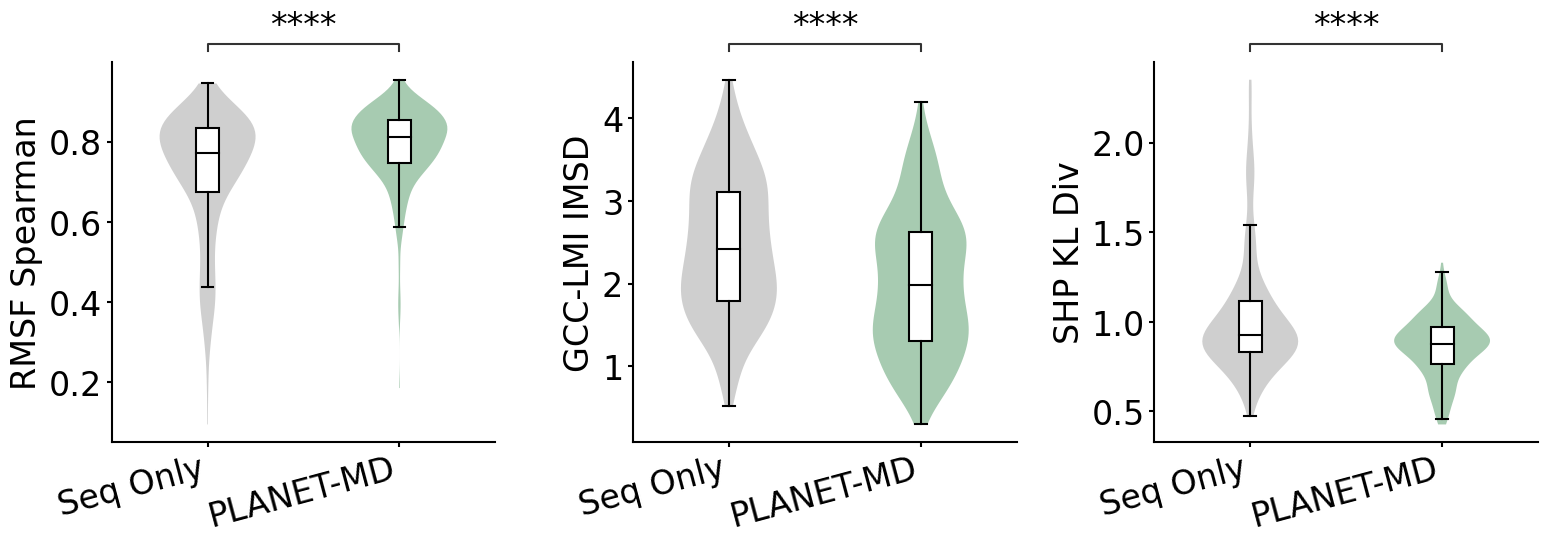

RMSF Spearman  Seq Only vs PLANET-MD: U=64061, p=2.058e-09, n=411 vs 411
GCC-LMI IMSD  Seq Only vs PLANET-MD: U=107696, p=8.707e-12, n=411 vs 411
SHP KL Div  Seq Only vs PLANET-MD: U=105949, p=2.734e-10, n=411 vs 411


In [92]:
def _violin_box_single(ax, vals, x_center, color, violin_width=0.5, box_width=0.12):
    if vals.std() > 1e-9:
        vp = ax.violinplot(vals, positions=[x_center], widths=violin_width,
                           showmeans=False, showmedians=False, showextrema=False)
        for body in vp["bodies"]:
            body.set_facecolor(color)
            body.set_alpha(0.4)
            body.set_edgecolor("none")

    q1, med, q3 = np.percentile(vals, [25, 50, 75])
    iqr = q3 - q1
    lo = max(vals.min(), q1 - 1.5 * iqr)
    hi = min(vals.max(), q3 + 1.5 * iqr)
    bw = box_width
    rect = mpatches.FancyBboxPatch(
        (x_center - bw / 2, q1), bw, iqr,
        boxstyle="square,pad=0",
        linewidth=1.5, edgecolor="black", facecolor="white", zorder=3,
    )
    ax.add_patch(rect)
    ax.plot([x_center - bw / 2, x_center + bw / 2], [med, med],
            color="black", linewidth=1.5, zorder=4)
    ax.plot([x_center, x_center], [q1, lo], color="black", linewidth=1.5, zorder=3)
    ax.plot([x_center, x_center], [q3, hi], color="black", linewidth=1.5, zorder=3)
    cap_w = bw * 0.5
    for cap_y in [lo, hi]:
        ax.plot([x_center - cap_w / 2, x_center + cap_w / 2], [cap_y, cap_y],
                color="black", linewidth=1.5, zorder=3)


fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, (struct_col, seq_col, label) in zip(axes, metrics_cfg):
    _violin_box_single(ax, all_results[seq_col].dropna().values,    0, seq_color)
    _violin_box_single(ax, all_results[struct_col].dropna().values, 1, struct_color)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Seq Only", "PLANET-MD"], rotation=15, ha="right")
    ax.set_ylabel(label)
    ax.set_xlim(-0.5, 1.5)

    annot_df = pd.DataFrame({
        "group": (["Seq Only"] * len(all_results[seq_col].dropna())
                  + ["PLANET-MD"] * len(all_results[struct_col].dropna())),
        "value": pd.concat([all_results[seq_col].dropna(),
                            all_results[struct_col].dropna()]).values,
    })
    annotator = Annotator(
        ax, [("Seq Only", "PLANET-MD")],
        data=annot_df, x="group", y="value",
        order=["Seq Only", "PLANET-MD"],
    )
    annotator.configure(test="Mann-Whitney", text_format="star", loc="outside", verbose=0)
    annotator.apply_and_annotate()

    finalize(ax)

plt.tight_layout()
plt.savefig(SVG_DIR / "fig7c_struct_ablation_violin.svg")
plt.show()

# ── Significance stats for caption ──────────────────────────────────────
from scipy.stats import mannwhitneyu as _mwu
for struct_col, seq_col_name, label in metrics_cfg:
    _x = all_results[seq_col_name].dropna().values
    _y = all_results[struct_col].dropna().values
    _u, _p = _mwu(_x, _y, alternative="two-sided")
    print(f"{label}  Seq Only vs PLANET-MD: U={_u:.0f}, p={_p:.3e}, n={len(_x)} vs {len(_y)}")
